<center><h1>Team 5 Final Project</h1>
<br>
Daniel Arday, Gabriel Kolon, Kimberly Vierczhalek</center>

# Introduction

In this project, we focused on developing a machine learning system for facial emotion recognition using the **FER2013 dataset**. The **FER2013** (Facial Expression Recognition 2013) dataset is a widely used benchmark dataset for emotion classification, containing **35,887 grayscale images of human faces**, each labeled with one of **seven emotion categories**: **Angry, Disgust, Fear, Happy, Neutral, Sad, and Surprised**. The dataset was originally introduced as part of the **ICML 2013 Challenges in Representation Learning** and has since become a standard for training deep learning models in affective computing.

Our goal was to **build an end-to-end machine learning pipeline** capable of accurately classifying facial expressions into these seven emotion classes. We framed this as a **multi-class classification problem**, where a deep learning model would take an input image and predict the corresponding emotion label. Given the potential applications in **human-computer interaction, mental health monitoring, and AI-driven emotion analysis**, this problem holds significant real-world value.

Throughout this project, we incorporated **MLOps best practices** to ensure a **scalable, production-ready system**. This included:  
- **Data preprocessing**: Cleaning, augmenting, and preparing the FER2013 dataset for training.  
- **Model development**: Experimenting with deep learning architectures, such as **CNNs and transfer learning models**, to improve accuracy.  
- **Model deployment**: Hosting the trained model on **AWS SageMaker** for real-time inference.  
- **CI/CD pipelines**: Automating model retraining and deployment workflows for continuous improvement.  
- **Monitoring and validation**: Implementing logging, performance tracking, and ethical considerations to assess model biases and fairness.  

By the end of this project, we successfully **trained, evaluated, and deployed a facial emotion recognition model**, demonstrating the full **MLOps lifecycle** from data ingestion to model monitoring. 

The following sections detail our approach, technical implementation, and key findings:


1. Exploratory Data Analysis
2. 

### Imports & Installs

In [10]:
!pip install kaggle boto3
!pip install tensorflow-addons

In [4]:
# Shared imports

import os
import zipfile
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import cv2
from PIL import Image

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator, smart_resize

from sklearn.model_selection import train_test_split
from scipy.stats import entropy

import kagglehub

# Exploratory Data Analysis (EDA)  

Before setting up our pipeline, we first conducted basic exploratory data analysis (EDA) to better understand the structure and distribution of the dataset. This included examining **class distributions, pixel intensity trends, and entropy measures** to identify potential challenges and preprocessing needs.  

In [1]:
# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

100%|██████████| 60.3M/60.3M [00:01<00:00, 44.1MB/s]


Extracting files...
Path to dataset files: C:\Users\gabri\.cache\kagglehub\datasets\msambare\fer2013\versions\1


## Preview of the Data

Training set sample images:


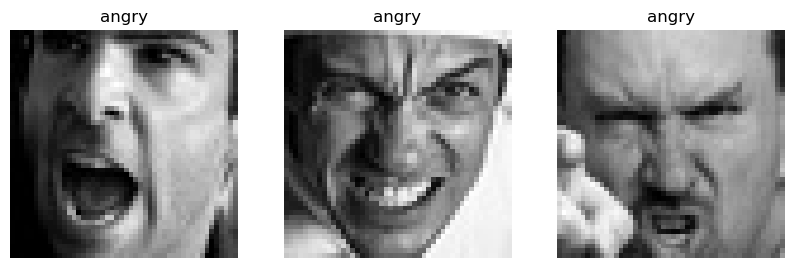

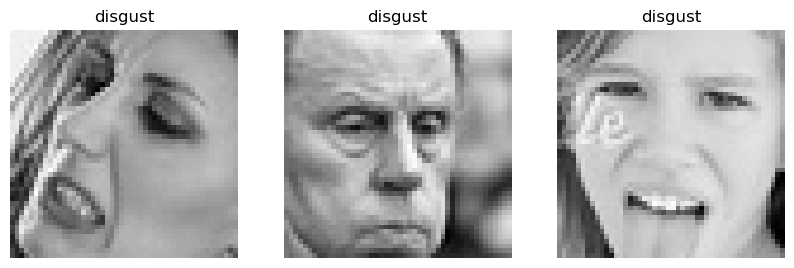

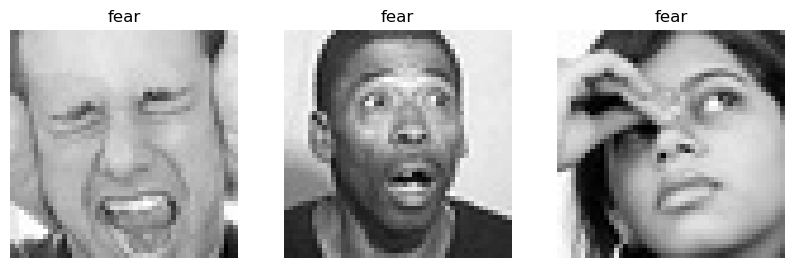

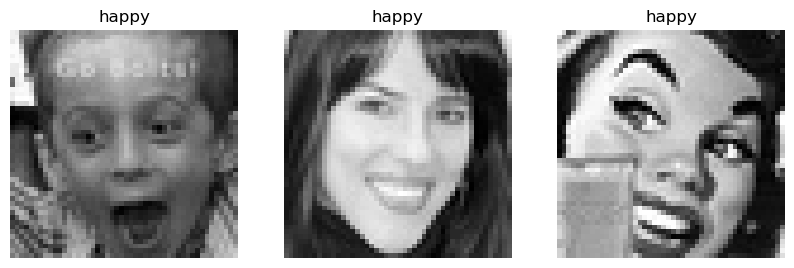

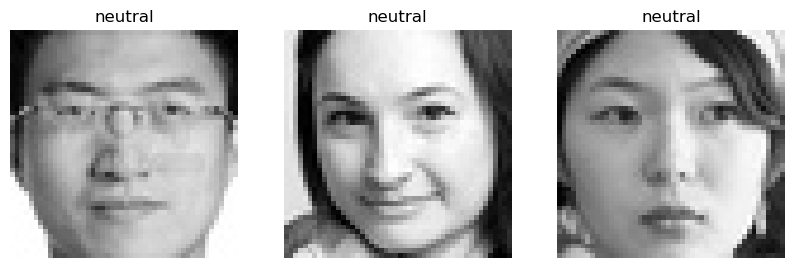

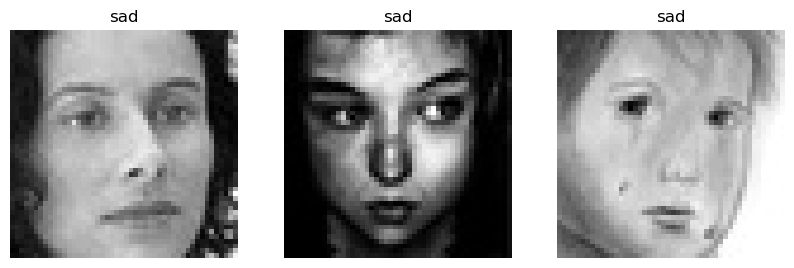

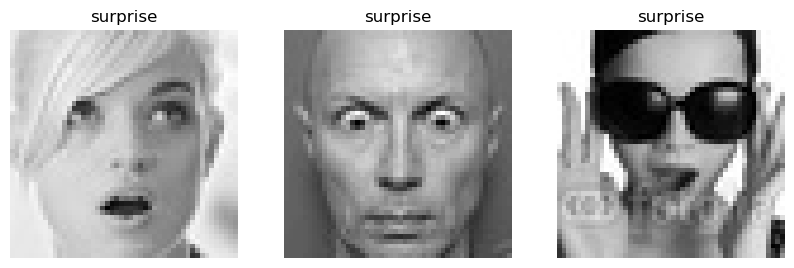

Testing set sample images:


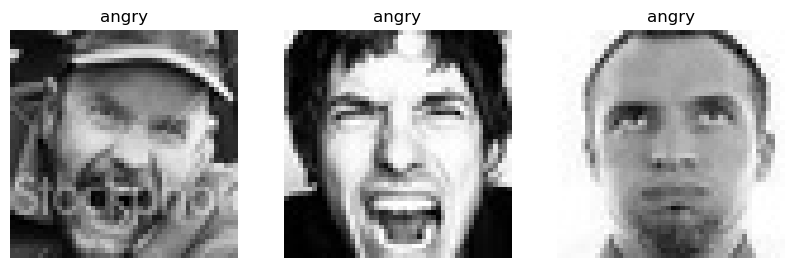

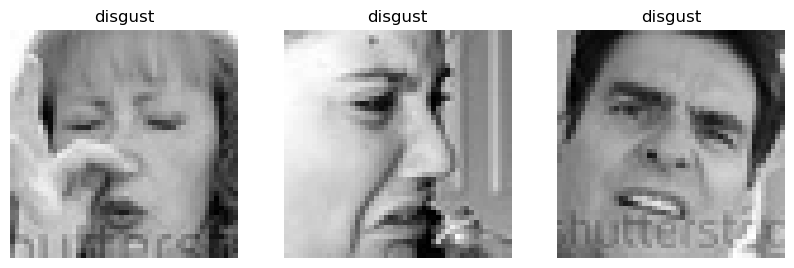

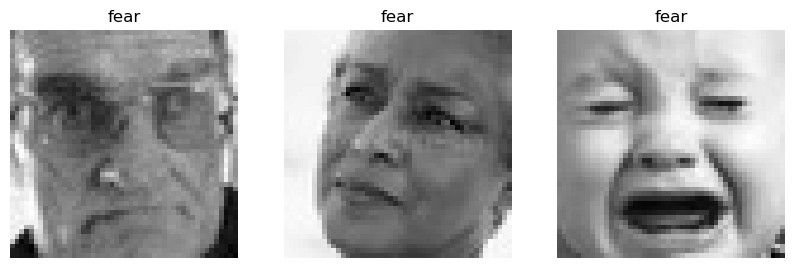

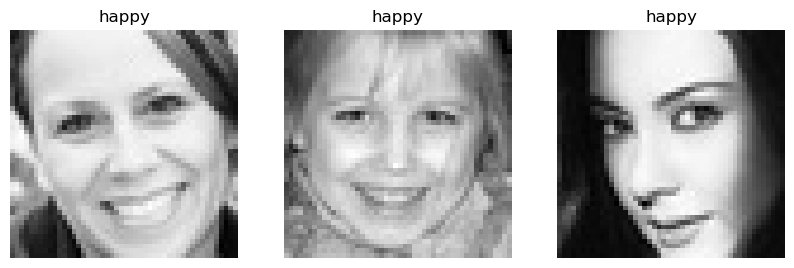

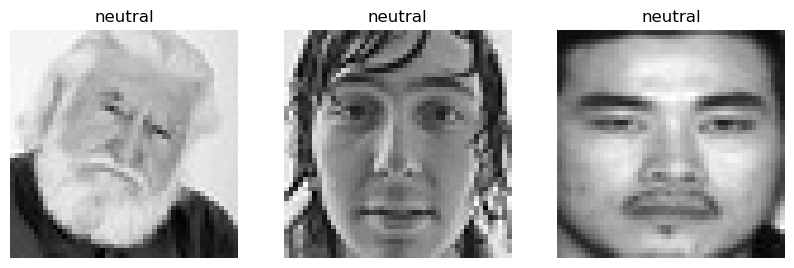

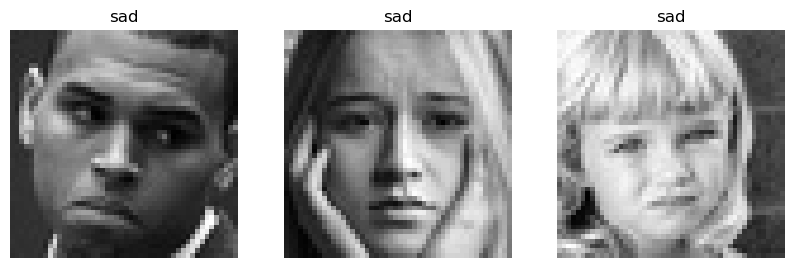

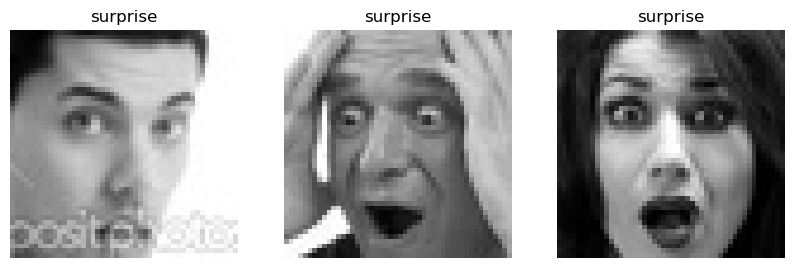

In [18]:
def plot_random_images(base_dir, num_images=3):
    for subdir in os.listdir(base_dir):
        subdir_path = os.path.join(base_dir, subdir)
        if os.path.isdir(subdir_path):
            images = random.sample(os.listdir(subdir_path), num_images)
            plt.figure(figsize=(10, 5))
            for i, image_name in enumerate(images):
                image_path = os.path.join(subdir_path, image_name)
                image = Image.open(image_path)
                plt.subplot(1, num_images, i + 1)
                plt.imshow(image, cmap='gray')
                plt.title(subdir)
                plt.axis('off')
            plt.show()

print("Training set sample images:")
plot_random_images(train_dir)

print("Testing set sample images:")
plot_random_images(test_dir)

## Exploring Data Distributions

In [4]:
def count_images_in_subdirectories(base_dir):
    counts = {}
    for subdir in os.listdir(base_dir):
        subdir_path = os.path.join(base_dir, subdir)
        if os.path.isdir(subdir_path):
            counts[subdir] = len(os.listdir(subdir_path))
    return counts

train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')

train_counts = count_images_in_subdirectories(train_dir)
test_counts = count_images_in_subdirectories(test_dir)

print("Training set counts:", train_counts)
print("Testing set counts:", test_counts)

Training set counts: {'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}
Testing set counts: {'angry': 958, 'disgust': 111, 'fear': 1024, 'happy': 1774, 'neutral': 1233, 'sad': 1247, 'surprise': 831}


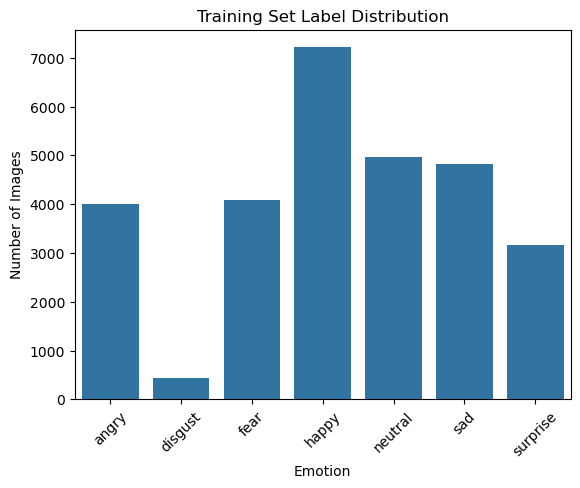

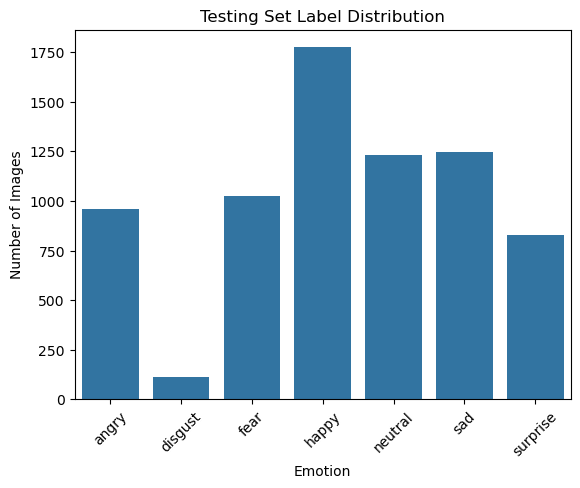

In [8]:
def plot_label_distribution(counts, title):
    sns.barplot(x=list(counts.keys()), y=list(counts.values()))
    plt.title(title)
    plt.ylabel("Number of Images")
    plt.xlabel("Emotion")
    plt.xticks(rotation=45)
    plt.show()

plot_label_distribution(train_counts, "Training Set Label Distribution")
plot_label_distribution(test_counts, "Testing Set Label Distribution")


The model may struggle to learn to recognize the emotion of 'disgust' due to the lack of data on it. 
We shouyld consider supplementing the data with more images so that the model distribution can be balanced.

The training and test directories are proportional. 

## Exploring Pixel Intensity

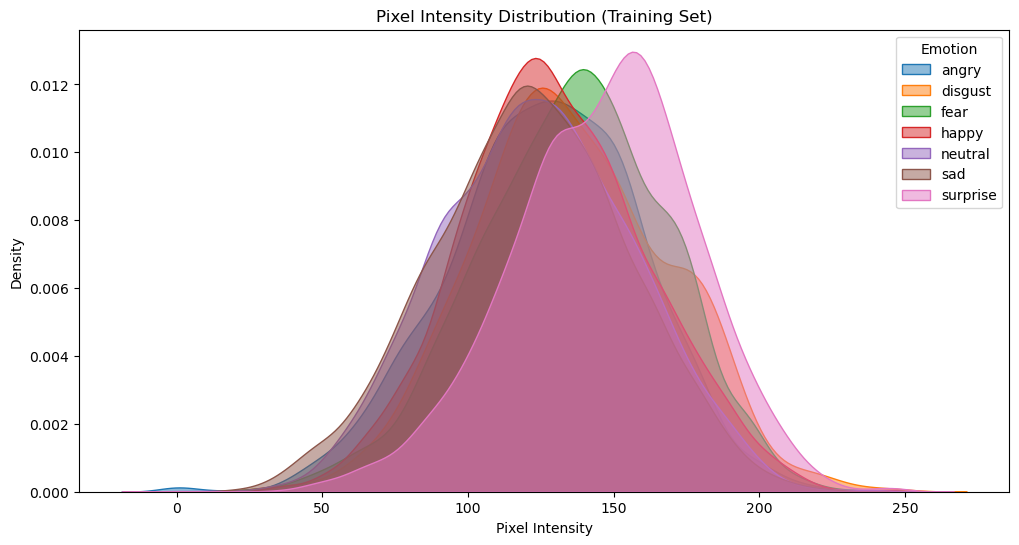

In [9]:
def compute_pixel_intensity_distribution(base_dir):
    intensity_data = {}

    for subdir in os.listdir(base_dir):
        subdir_path = os.path.join(base_dir, subdir)
        if os.path.isdir(subdir_path):
            intensities = []
            for image_name in os.listdir(subdir_path):
                image_path = os.path.join(subdir_path, image_name)
                image = Image.open(image_path).convert('L')  # Convert to grayscale
                intensities.append(np.array(image).flatten().mean())  # Compute mean pixel intensity
            intensity_data[subdir] = intensities
    return intensity_data

def plot_pixel_intensity_distribution(intensity_data, title):
    plt.figure(figsize=(12, 6))
    for category, intensities in intensity_data.items():
        sns.kdeplot(intensities, label=category, fill=True, alpha=0.5)
    plt.title(title)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Density")
    plt.legend(title="Emotion")
    plt.show()

# Compute pixel intensity distribution for the training dataset
train_intensity_data = compute_pixel_intensity_distribution(train_dir)

# Plot the distribution
plot_pixel_intensity_distribution(train_intensity_data, "Pixel Intensity Distribution (Training Set)")


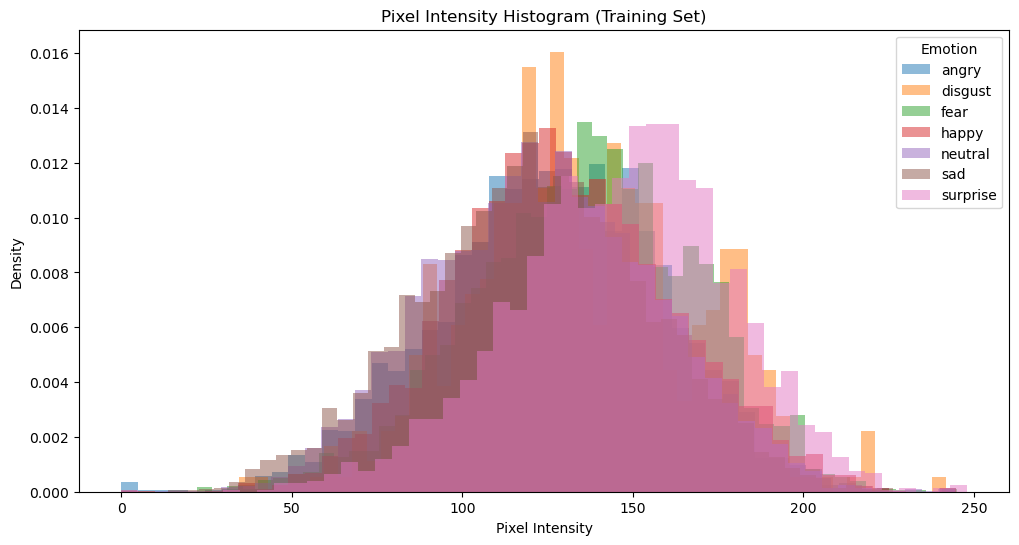

In [10]:
def plot_pixel_intensity_histogram(intensity_data, title):
    plt.figure(figsize=(12, 6))
    for category, intensities in intensity_data.items():
        plt.hist(intensities, bins=50, alpha=0.5, label=category, density=True)
    plt.title(title)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Density")
    plt.legend(title="Emotion")
    plt.show()

# Plot histogram of pixel intensity
plot_pixel_intensity_histogram(train_intensity_data, "Pixel Intensity Histogram (Training Set)")


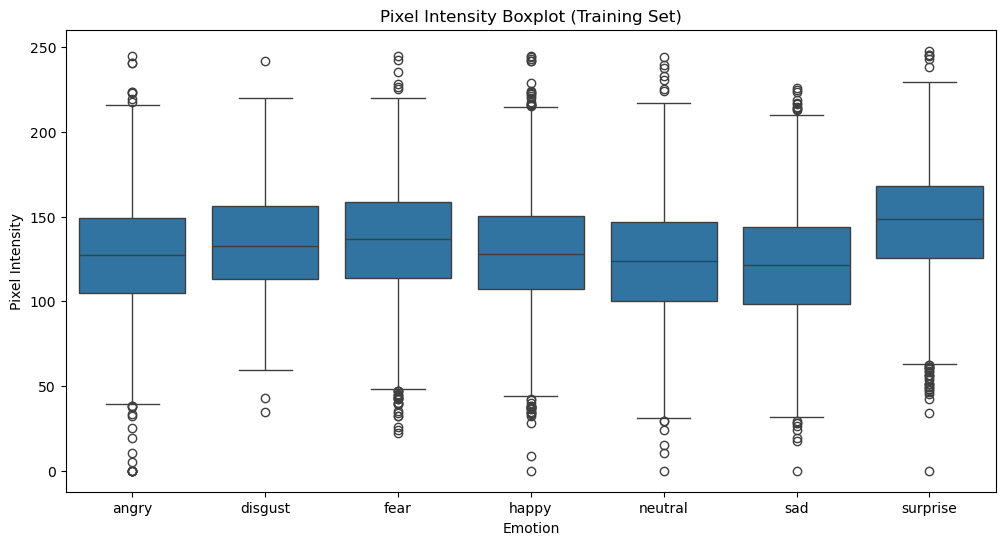

In [11]:
def plot_pixel_intensity_boxplot(intensity_data, title):
    data = []
    for category, intensities in intensity_data.items():
        data.extend([(category, intensity) for intensity in intensities])
    df = pd.DataFrame(data, columns=['Emotion', 'Pixel Intensity'])
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Emotion', y='Pixel Intensity', data=df)
    plt.title(title)
    plt.xlabel("Emotion")
    plt.ylabel("Pixel Intensity")
    plt.show()

# Plot boxplot of pixel intensity
plot_pixel_intensity_boxplot(train_intensity_data, "Pixel Intensity Boxplot (Training Set)")


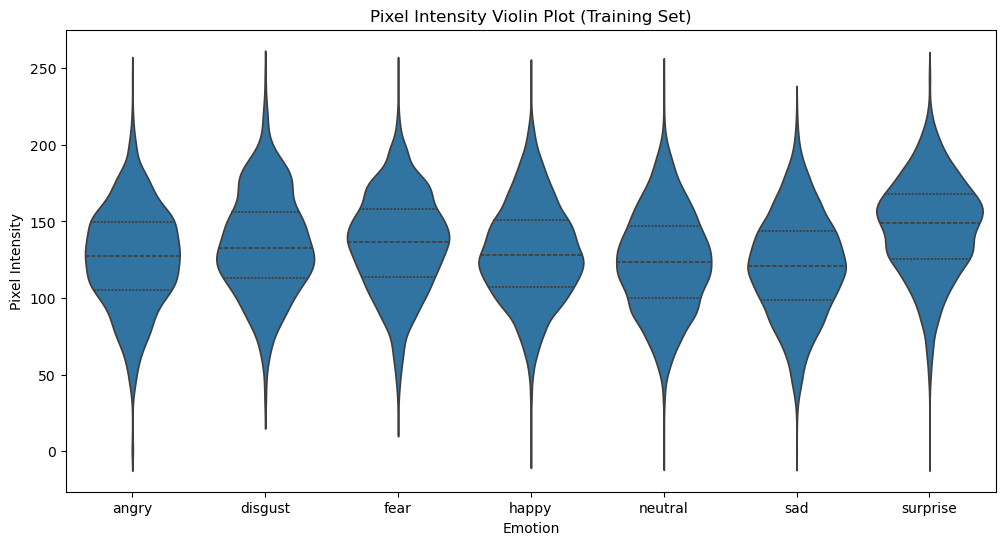

In [12]:
def plot_pixel_intensity_violinplot(intensity_data, title):
    data = []
    for category, intensities in intensity_data.items():
        data.extend([(category, intensity) for intensity in intensities])
    df = pd.DataFrame(data, columns=['Emotion', 'Pixel Intensity'])
    
    plt.figure(figsize=(12, 6))
    sns.violinplot(x='Emotion', y='Pixel Intensity', data=df, inner='quartile')
    plt.title(title)
    plt.xlabel("Emotion")
    plt.ylabel("Pixel Intensity")
    plt.show()

# Plot violin plot of pixel intensity
plot_pixel_intensity_violinplot(train_intensity_data, "Pixel Intensity Violin Plot (Training Set)")

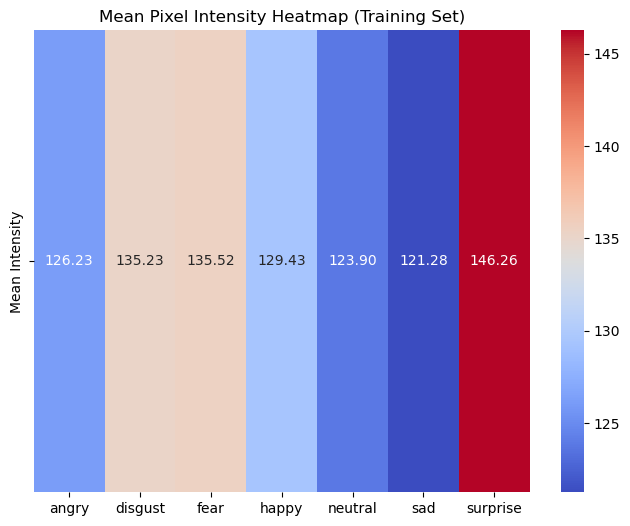

In [13]:
def plot_pixel_intensity_heatmap(intensity_data, title):
    mean_intensities = {category: np.mean(intensities) for category, intensities in intensity_data.items()}
    categories = list(mean_intensities.keys())
    values = list(mean_intensities.values())

    plt.figure(figsize=(8, 6))
    sns.heatmap([values], annot=True, fmt=".2f", xticklabels=categories, yticklabels=["Mean Intensity"], cmap="coolwarm")
    plt.title(title)
    plt.show()

# Plot heatmap of mean pixel intensity
plot_pixel_intensity_heatmap(train_intensity_data, "Mean Pixel Intensity Heatmap (Training Set)")

Interestingly enough, the 'surprise' emotion has the higher pixel intensity on average, which is an emotion that is describe as having 'brightness' 

brightness could be interpreted as face surface area, and lack of shadows

##  Exploring Edges

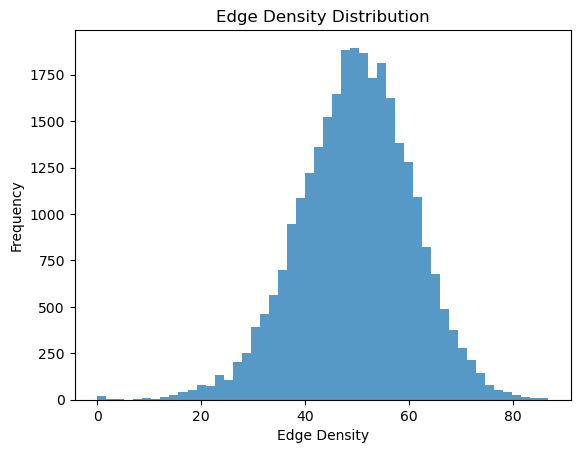

In [14]:
import cv2

def compute_edge_density(base_dir):
    edge_densities = []
    for subdir in os.listdir(base_dir):
        subdir_path = os.path.join(base_dir, subdir)
        if os.path.isdir(subdir_path):
            for image_name in os.listdir(subdir_path):
                image_path = os.path.join(subdir_path, image_name)
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                edges = cv2.Canny(image, 100, 200)
                edge_density = edges.sum() / edges.size
                edge_densities.append(edge_density)
    return edge_densities

edge_densities = compute_edge_density(train_dir)

# Plot edge density
plt.hist(edge_densities, bins=50, alpha=0.75)
plt.title("Edge Density Distribution")
plt.xlabel("Edge Density")
plt.ylabel("Frequency")
plt.show()


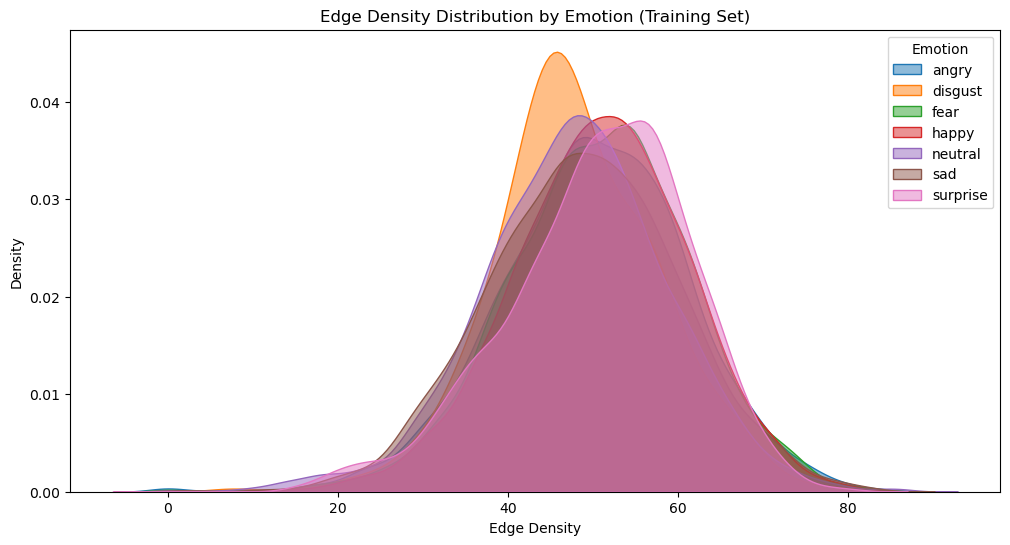

In [16]:

def compute_edge_density_by_emotion(base_dir):
    edge_densities_by_emotion = {}

    for subdir in os.listdir(base_dir):
        subdir_path = os.path.join(base_dir, subdir)
        if os.path.isdir(subdir_path):
            edge_densities = []
            for image_name in os.listdir(subdir_path):
                image_path = os.path.join(subdir_path, image_name)
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                edges = cv2.Canny(image, 100, 200)
                edge_density = edges.sum() / edges.size
                edge_densities.append(edge_density)
            edge_densities_by_emotion[subdir] = edge_densities

    return edge_densities_by_emotion

# Compute edge densities for the training dataset
edge_densities_by_emotion = compute_edge_density_by_emotion(train_dir)

# Plot edge density distribution for each emotion
def plot_edge_density_by_emotion(edge_densities_by_emotion, title):
    plt.figure(figsize=(12, 6))
    for emotion, densities in edge_densities_by_emotion.items():
        sns.kdeplot(densities, label=emotion, fill=True, alpha=0.5)
    plt.title(title)
    plt.xlabel("Edge Density")
    plt.ylabel("Density")
    plt.legend(title="Emotion")
    plt.show()

# Plot the results
plot_edge_density_by_emotion(edge_densities_by_emotion, "Edge Density Distribution by Emotion (Training Set)")

## Exploring Entropy

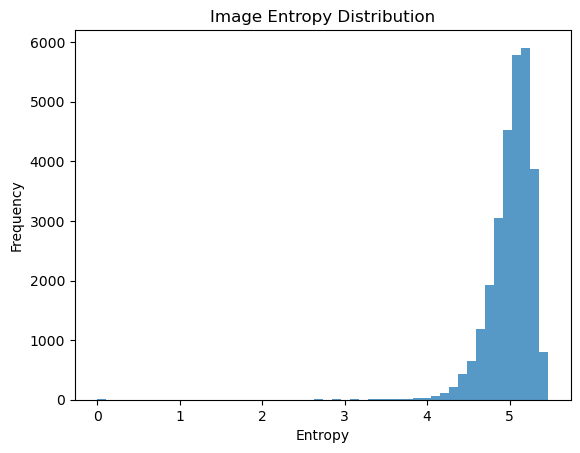

In [15]:
def compute_image_entropy(base_dir):
    entropies = []
    for subdir in os.listdir(base_dir):
        subdir_path = os.path.join(base_dir, subdir)
        if os.path.isdir(subdir_path):
            for image_name in os.listdir(subdir_path):
                image_path = os.path.join(subdir_path, image_name)
                image = Image.open(image_path).convert('L')
                hist = np.histogram(np.array(image).flatten(), bins=256, range=(0, 255))[0]
                hist = hist / hist.sum()
                entropies.append(entropy(hist))
    return entropies

image_entropies = compute_image_entropy(train_dir)

# Plot entropy distribution
plt.hist(image_entropies, bins=50, alpha=0.75)
plt.title("Image Entropy Distribution")
plt.xlabel("Entropy")
plt.ylabel("Frequency")
plt.show()


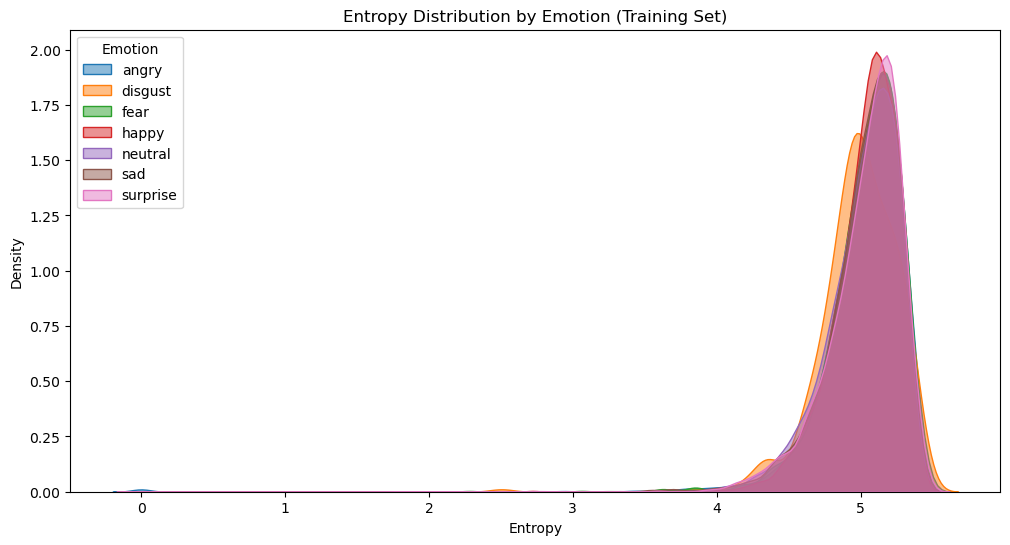

In [17]:
from scipy.stats import entropy
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

def compute_image_entropy_by_emotion(base_dir):
    entropy_by_emotion = {}

    for subdir in os.listdir(base_dir):
        subdir_path = os.path.join(base_dir, subdir)
        if os.path.isdir(subdir_path):
            entropies = []
            for image_name in os.listdir(subdir_path):
                image_path = os.path.join(subdir_path, image_name)
                image = Image.open(image_path).convert('L')  # Convert to grayscale
                hist = np.histogram(np.array(image).flatten(), bins=256, range=(0, 255))[0]
                hist = hist / hist.sum()  # Normalize the histogram
                entropies.append(entropy(hist))  # Calculate entropy
            entropy_by_emotion[subdir] = entropies

    return entropy_by_emotion

# Compute entropy for each emotion
entropy_by_emotion = compute_image_entropy_by_emotion(train_dir)

# Plot entropy distribution for each emotion
def plot_entropy_distribution(entropy_by_emotion, title):
    plt.figure(figsize=(12, 6))
    for emotion, entropies in entropy_by_emotion.items():
        sns.kdeplot(entropies, label=emotion, fill=True, alpha=0.5)
    plt.title(title)
    plt.xlabel("Entropy")
    plt.ylabel("Density")
    plt.legend(title="Emotion")
    plt.show()

# Plot the results
plot_entropy_distribution(entropy_by_emotion, "Entropy Distribution by Emotion (Training Set)")


Since faces are complex it makes sense that the images are all higher on the entropy scale. There does not appear to be much significant difference between the density distributions of each emotion to consider entropy in this case. 

## Conclusions on EDA  

1. **Class Imbalance** – The dataset is **imbalanced**, with **happy** (7,215 images) being the most common and **disgust** (436 images) the least. This may hinder model performance, requiring **augmentation** or additional data.  

2. **Pixel Intensity** – Intensity distributions are **similar across emotions**, making raw pixel values weak distinguishing features. **Spatial features (edges, contours)** may be more useful.  

3. **Edge Density** – Follows a **normal distribution** with no significant outliers, suggesting **limited impact** on classification but still worth refining.  

4. **Dataset Proportions** – Training and testing sets are **proportionally distributed**, ensuring fair generalization with no major **data leakage concerns**.

# Face Detection Process  

To prepare images for emotion classification, we first implemented **face detection** using **Haar Cascade classifiers**, to ensures that our model focuses only on relevant facial regions for images fed to it.

### Steps Taken:  
1. **Loaded the Haar Cascade Classifier** – Used OpenCV’s pre-trained **haarcascade_frontalface_default.xml** model for face detection.  
2. **Preprocessed the Image** – Converted the input image to grayscale to improve detection accuracy.  
3. **Detected Faces** – Applied the Haar Cascade detector to identify face bounding boxes.  
4. **Cropped and Resized Faces** – Extracted detected faces and resized them to **48x48 pixels**, matching the FER2013 dataset format.  
5. **Stored Processed Faces** – Saved individual face images for further emotion classification.  

### Why This Matters:  
Detecting and cropping faces ensures **consistent input dimensions**, reduces noise, and improves model performance by focusing on facial features. This step is crucial in real-world applications where images vary in size, lighting, and background complexity.

In [2]:
# Setting the path for the Cascade module:
cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"

# Making sure the file exists:
if not os.path.exists(cascade_path):
    raise FileNotFoundError(f"Haar cascade file not found at {cascade_path}")

# Initiating the face cascade classifier:
face_cascade = cv2.CascadeClassifier(cascade_path)


In [3]:
# Loading the sample image:
image_path = "C:\MSAAI\AAI-540\Team Project\Images\sample_img.png"
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Image not found at {image_path}")

In [4]:
ext = os.path.splitext(image_path)[1].lower()
if ext not in ['.jpg', '.jpeg']:
    
    # Converting the image to JPG format:
    new_image_path = os.path.splitext(image_path)[0] + ".jpg"
    cv2.imwrite(new_image_path, image)
    print(f"Image was not in JPG format (found {ext}). Converted and saved as {new_image_path}.")
    
    # Updating the image_path if necessary:
    image_path = new_image_path
    image = cv2.imread(image_path)

Image was not in JPG format (found .png). Converted and saved as C:\MSAAI\AAI-540\Team Project\Images\sample_img.jpg.


In [5]:
# Converting the image to grayscale:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [6]:
# Detecting faces in the image:
faces = face_cascade.detectMultiScale(gray_image, scaleFactor=1.1, minNeighbors=5)

print(f"Detected {len(faces)} face(s) using Haar Cascade.")

Detected 5 face(s) using Haar Cascade.


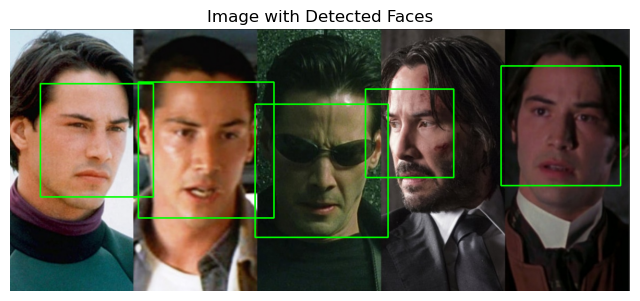

In [7]:
# Drawing bounding boxes on the original image:
for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

# Converting the image to RGB:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Displaying the image with bounding boxes around the face(s):
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Image with Detected Faces")
plt.axis("off")
plt.show()


In [8]:
# Creating a list to store processed face images:
face_images = []

#  Processing each detected face
for idx, (x, y, w, h) in enumerate(faces):
    # Cropping the facial region(s) from the original image:
    face_roi = image[y:y+h, x:x+w]
    
    # Resizing the face(s) to 48x48 pixels:
    face_resized = cv2.resize(face_roi, (48, 48))
    
    # Converting the resized face(s) to grayscale (if not already):
    if len(face_resized.shape) == 3 and face_resized.shape[2] == 3:
        face_gray = cv2.cvtColor(face_resized, cv2.COLOR_BGR2GRAY)
    else:
        face_gray = face_resized

    # Saving the processed face(s) image with a unique filename:
    output_dir = "C:\MSAAI\AAI-540\Team Project\Images"
    output_filename = os.path.join(output_dir, f"face_{idx}.png")
    cv2.imwrite(output_filename, face_gray)
    print(f"Saved face {idx} as {output_filename}")

    # Appending the processed face(s) to the list:
    face_images.append(face_gray)


Saved face 0 as C:\MSAAI\AAI-540\Team Project\Images\face_0.png
Saved face 1 as C:\MSAAI\AAI-540\Team Project\Images\face_1.png
Saved face 2 as C:\MSAAI\AAI-540\Team Project\Images\face_2.png
Saved face 3 as C:\MSAAI\AAI-540\Team Project\Images\face_3.png
Saved face 4 as C:\MSAAI\AAI-540\Team Project\Images\face_4.png


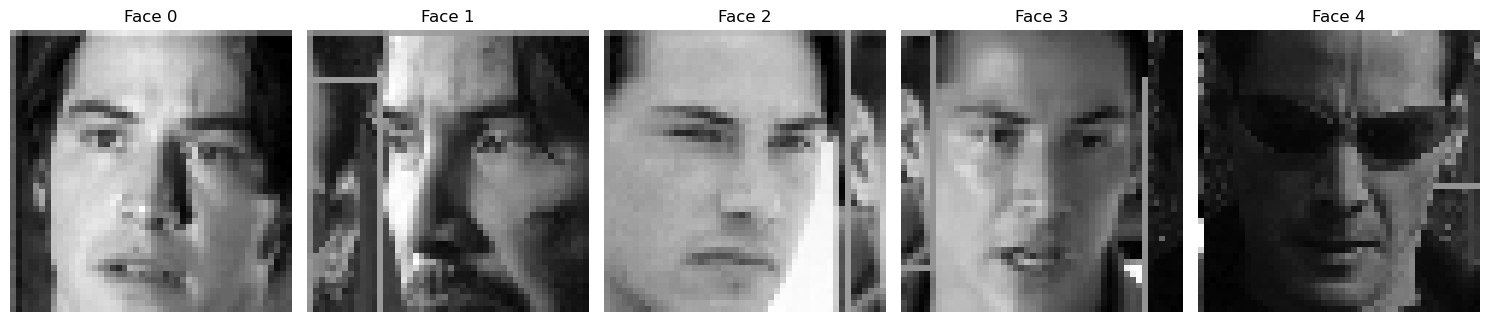

In [9]:
# Displaying all cropped face images in one figure:
num_faces = len(face_images)
plt.figure(figsize=(15, 5))
for idx, face in enumerate(face_images):
    plt.subplot(1, num_faces, idx + 1)
    plt.imshow(face, cmap='gray')
    plt.title(f"Face {idx}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Feature Store  

To manage and track our dataset efficiently, we utilized **AWS S3 and Amazon Athena** to store, query, and process image metadata. This ensures repeatability, scalability, and ease of access for downstream machine learning tasks.  

### Steps Taken:  

1. **Dataset Acquisition** – Downloaded the **FER2013 dataset** using the **Kaggle API** and stored it locally.  
2. **S3 Upload** – Uploaded the dataset to **AWS S3** for centralized storage and accessibility across SageMaker instances.  
3. **Metadata Extraction** – Collected key image properties (**filename, file path, label, dimensions, file size**) and saved them as **CSV and Parquet** files.  
4. **Athena Integration** – Created an **Athena database and external table** for efficient querying of image metadata without loading the full dataset.  

### Why This Matters:  
Storing image metadata in a structured format allows for **efficient data retrieval, preprocessing, and feature extraction** during model training. By leveraging **AWS Athena**, we can perform SQL-based queries on the dataset without excessive I/O operations, improving **scalability and reproducibility** in our ML pipeline.

### Kaggle API
This block of code uses the Kaggle API to grab the images. It is possible to import them a different way, but for repeatability this was the most straightforward. Follow the Kaggle API instructions for getting the API access token setup https://www.kaggle.com/docs/api.

In [2]:
# Grabbing dataset from kaggle api
import os 
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi() 
api.authenticate()

dataset_name = "msambare/fer2013"
download_dir = './fer2013'

api.dataset_download_files(dataset_name, path=download_dir, unzip=True)

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013


In [6]:
# This uploads all the images from the Kaggle Dataset to S3 
import os
import boto3
from tqdm import tqdm
import sagemaker

# Initialize S3 client
s3_client = boto3.client('s3')

# Initialize SageMaker session and S3 path
sess = sagemaker.Session()
bucket = sess.default_bucket()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
account_id = boto3.client("sts").get_caller_identity().get("Account")

# Define local path and S3 destination path
local_path = './fer2013'  # Path where the FER-2013 dataset is stored locally
s3_fer_path = f"s3://{bucket}/group-5/fer"
print(f"Uploading data to: {s3_fer_path}")

# Function to upload files maintaining the folder structure
def upload_directory_to_s3(local_path, s3_bucket_path):
    for subdir, dirs, files in tqdm(os.walk(local_path)):
        for file in files:
            local_file_path = os.path.join(subdir, file)
            
            # Construct the S3 path by preserving the folder structure
            relative_path = os.path.relpath(local_file_path, local_path)
            s3_file_path = os.path.join(s3_bucket_path, relative_path).replace("\\", "/")

            # Upload the file to S3 using boto3 client
            s3_client.upload_file(local_file_path, bucket, s3_file_path)
            print(f"Uploaded: {local_file_path} to {s3_file_path}")

# Call the function to upload the FER-2013 dataset
upload_directory_to_s3(local_path, s3_fer_path)

# Store the S3 path in a variable for later use
%store s3_fer_path


Uploading data to: s3://sagemaker-us-east-1-399018723364/group-5/fer


0it [00:00, ?it/s]

Uploaded: ./fer2013/test/angry/PrivateTest_10131363.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/test/angry/PrivateTest_10131363.jpg
Uploaded: ./fer2013/test/angry/PrivateTest_10304478.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/test/angry/PrivateTest_10304478.jpg
Uploaded: ./fer2013/test/angry/PrivateTest_1054527.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/test/angry/PrivateTest_1054527.jpg
Uploaded: ./fer2013/test/angry/PrivateTest_10590091.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/test/angry/PrivateTest_10590091.jpg
Uploaded: ./fer2013/test/angry/PrivateTest_1109992.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/test/angry/PrivateTest_1109992.jpg
Uploaded: ./fer2013/test/angry/PrivateTest_11296953.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/test/angry/PrivateTest_11296953.jpg
Uploaded: ./fer2013/test/angry/PrivateTest_12000629.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/test/angry/PrivateTest_12

3it [00:37, 12.62s/it]

Uploaded: ./fer2013/test/angry/PublicTest_99509833.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/test/angry/PublicTest_99509833.jpg
Uploaded: ./fer2013/test/angry/PublicTest_99607072.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/test/angry/PublicTest_99607072.jpg
Uploaded: ./fer2013/test/angry/PublicTest_99646813.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/test/angry/PublicTest_99646813.jpg
Uploaded: ./fer2013/test/angry/PublicTest_99743122.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/test/angry/PublicTest_99743122.jpg
Uploaded: ./fer2013/test/disgust/PrivateTest_11895083.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/test/disgust/PrivateTest_11895083.jpg
Uploaded: ./fer2013/test/disgust/PrivateTest_19671520.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/test/disgust/PrivateTest_19671520.jpg
Uploaded: ./fer2013/test/disgust/PrivateTest_21629266.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/test/disgust/Privat

...

Uploaded: ./fer2013/train/neutral/Training_99917717.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/neutral/Training_99917717.jpg
Uploaded: ./fer2013/train/neutral/Training_99959472.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/neutral/Training_99959472.jpg
Uploaded: ./fer2013/train/neutral/Training_99968496.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/neutral/Training_99968496.jpg
Uploaded: ./fer2013/train/neutral/Training_99969020.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/neutral/Training_99969020.jpg
Uploaded: ./fer2013/train/sad/Training_10022789.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/sad/Training_10022789.jpg
Uploaded: ./fer2013/train/sad/Training_10031481.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/sad/Training_10031481.jpg
Uploaded: ./fer2013/train/sad/Training_10048646.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/sad/Training_10048646.jpg
Uploaded:

16it [22:06, 166.94s/it]

Uploaded: ./fer2013/train/sad/Training_99943858.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/sad/Training_99943858.jpg
Uploaded: ./fer2013/train/sad/Training_99950687.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/sad/Training_99950687.jpg
Uploaded: ./fer2013/train/sad/Training_99987906.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/sad/Training_99987906.jpg
Uploaded: ./fer2013/train/sad/Training_99996831.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/sad/Training_99996831.jpg
Uploaded: ./fer2013/train/surprise/Training_10013223.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/surprise/Training_10013223.jpg
Uploaded: ./fer2013/train/surprise/Training_1002457.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/surprise/Training_1002457.jpg
Uploaded: ./fer2013/train/surprise/Training_10028230.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/surprise/Training_10028230.jpg
Uploaded: ./f

17it [24:11, 85.35s/it] 

Uploaded: ./fer2013/train/surprise/Training_99916297.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/surprise/Training_99916297.jpg
Uploaded: ./fer2013/train/surprise/Training_99924420.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/surprise/Training_99924420.jpg
Uploaded: ./fer2013/train/surprise/Training_99937001.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/surprise/Training_99937001.jpg
Uploaded: ./fer2013/train/surprise/Training_99951755.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/surprise/Training_99951755.jpg
Uploaded: ./fer2013/train/surprise/Training_99984132.jpg to s3://sagemaker-us-east-1-399018723364/group-5/fer/train/surprise/Training_99984132.jpg
Stored 's3_fer_path' (str)


## Feature Store Basic Metadata Info
The following code collects basic info about each of the files in the database. This includes the location, the label, the event time (of upload), and the size. This information is converted to CSV and Parquet files for processing and storage in a SQL database. This information is useful when extracting features and training the model. This table is simplistic, but suits the needs of a computer vision task. 

In [7]:
import os
from PIL import Image
import pandas as pd

# Directory where the images are stored
image_dir = './fer2013'

# Prepare an empty list to store metadata
metadata = []

# Loop over all the images in the directory (keeping folder structure intact)
for subdir, dirs, files in os.walk(image_dir):
    for file in files:
        if file.endswith('.jpg') or file.endswith('.jpeg'):
            # Get the file path
            file_path = os.path.join(subdir, file)
            
            # Open the image to extract metadata
            img = Image.open(file_path)
            width, height = img.size
            file_size = os.path.getsize(file_path)  # Size in bytes
            
            # Optionally, you can also extract labels if stored in the folder structure or filename
            label = subdir.split('/')[-1]  # Assuming folder names are the labels
            
            # Append metadata to the list
            metadata.append({
                'image_filename': file,
                'image_filepath': file_path,
                'label': label,
                'width': width,
                'height': height,
                'file_size': file_size
            })

# Convert the metadata list to a pandas DataFrame
df_metadata = pd.DataFrame(metadata)

# Save the metadata to a CSV file
df_metadata.to_csv('image_metadata.csv', index=False)
# Also save to parquet since this is a relatively large dataset
df_metadata.to_parquet('image_metadata.parquet')

In [35]:
# Connect to S3 to create a table based on generated csv file above
import boto3
import sagemaker
import pandas as pd

sess = sagemaker.Session()
bucket = sess.default_bucket()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
account_id = boto3.client("sts").get_caller_identity().get("Account")

sm = boto3.Session().client(service_name="sagemaker", region_name=region)

In [36]:
s3_metadata_path = "s3://{}/group-5/metadata".format(bucket)
print(s3_metadata_path)

s3://sagemaker-us-east-1-399018723364/group-5/metadata


In [37]:
%store s3_metadata_path

Stored 's3_metadata_path' (str)


In [55]:
!aws s3 cp /home/sagemaker-user/AAI_540-Group-Project/image_metadata.csv $s3_metadata_path/

upload: ./image_metadata.csv to s3://sagemaker-us-east-1-399018723364/group-5/metadata/image_metadata.csv


In [56]:
!aws s3 ls $s3_metadata_path/

2025-02-02 22:03:04    3015873 image_metadata.csv


In [59]:
sess = sagemaker.Session()
bucket = sess.default_bucket()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
ingest_create_athena_db_passed = False


In [60]:
from pyathena import connect
import pandas as pd
database_name = "eda_query"
s3_staging_dir = "s3://{0}/athena/staging".format(bucket)
conn = connect(region_name=region, s3_staging_dir=s3_staging_dir)

statement = "CREATE DATABASE IF NOT EXISTS {}".format(database_name)
print(statement)

pd.read_sql(statement, conn)

CREATE DATABASE IF NOT EXISTS eda_query


/tmp/ipykernel_122/261733862.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(statement, conn)


""


In [61]:
statement = "SHOW DATABASES"

df_show = pd.read_sql(statement, conn)
df_show.head(5)

if database_name in df_show.values:
    ingest_create_athena_db_passed = True

/tmp/ipykernel_122/1238219257.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_show = pd.read_sql(statement, conn)


In [62]:
if database_name in df_show.values:
    ingest_create_athena_db_passed = True

In [63]:
%store ingest_create_athena_db_passed

Stored 'ingest_create_athena_db_passed' (bool)


In [64]:
print(ingest_create_athena_db_passed)
table_name_csv = "fer_eda"
print(s3_metadata_path)

True
s3://sagemaker-us-east-1-399018723364/group-5/metadata


In [74]:
!aws s3 ls $s3_metadata_path/

2025-02-02 22:03:04    3015873 image_metadata.csv


In [73]:
statement = "DROP TABLE IF EXISTS {}.fer_eda".format(database_name)
df_show = pd.read_sql(statement, conn)

/tmp/ipykernel_122/3939622854.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_show = pd.read_sql(statement, conn)


In [75]:
statement = """CREATE EXTERNAL TABLE IF NOT EXISTS {}.{}(
         image_filename string,
         image_filepath string,
         label string,
         width int,
         height int,
         file_size int
) 
ROW FORMAT DELIMITED 
FIELDS TERMINATED BY ',' 
LINES TERMINATED BY '\\n' 
LOCATION '{}'
TBLPROPERTIES ('compressionType'='none', 'skip.header.line.count'='1')""".format(
    database_name, table_name_csv, s3_metadata_path
)

print(statement)

CREATE EXTERNAL TABLE IF NOT EXISTS eda_query.fer_eda(
         image_filename string,
         image_filepath string,
         label string,
         width int,
         height int,
         file_size int
) 
ROW FORMAT DELIMITED 
FIELDS TERMINATED BY ',' 
LINES TERMINATED BY '\n' 
LOCATION 's3://sagemaker-us-east-1-399018723364/group-5/metadata'
TBLPROPERTIES ('compressionType'='none', 'skip.header.line.count'='1')


In [76]:
pd.read_sql(statement, conn)


/tmp/ipykernel_122/1699531466.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(statement, conn)


""


In [77]:
statement = 'SHOW TABLES in {}'.format(database_name)

df_show = pd.read_sql(statement, conn)
df_show

/tmp/ipykernel_122/1747885984.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_show = pd.read_sql(statement, conn)


,tab_name
0,fer_eda


## Feature Store Demonstration 
This section preforms one example of EDA to demonstrate that the Feature Store is working correctly.

/tmp/ipykernel_122/1292093329.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


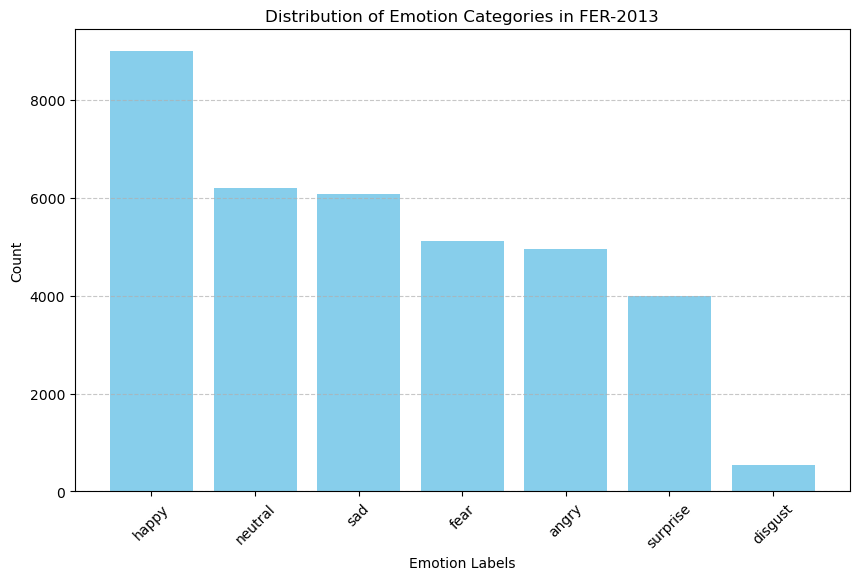

In [79]:
import matplotlib.pyplot as plt
# Query to get label distribution
query = f"SELECT label, COUNT(*) as count FROM {database_name}.{table_name_csv} GROUP BY label ORDER BY count DESC"
df = pd.read_sql(query, conn)

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.bar(df['label'], df['count'], color='skyblue')
plt.xlabel("Emotion Labels")
plt.ylabel("Count")
plt.title("Distribution of Emotion Categories in FER-2013")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

## Saving the Feature Store
This section saves the feature information gathered from each image, collected above and stores it in an AWS FeatureStore.

In [2]:
import boto3
import sagemaker

original_boto3_version = boto3.__version__
%pip install 'boto3>1.17.21'

Note: you may need to restart the kernel to use updated packages.


In [3]:
from sagemaker.session import Session

region = boto3.Session().region_name

boto_session = boto3.Session(region_name=region)

sagemaker_client = boto_session.client(service_name="sagemaker", region_name=region)
featurestore_runtime = boto_session.client(
    service_name="sagemaker-featurestore-runtime", region_name=region
)

feature_store_session = Session(
    boto_session=boto_session,
    sagemaker_client=sagemaker_client,
    sagemaker_featurestore_runtime_client=featurestore_runtime,
)

In [4]:
# Setup offline feature store in s3
default_s3_bucket_name = feature_store_session.default_bucket()
prefix = "sagemaker-featurestore-fer2013"


In [11]:
from sagemaker import get_execution_role

role = get_execution_role()
print(role)

arn:aws:iam::399018723364:role/LabRole


### Define FeatureGroups

In [5]:
from time import gmtime, strftime, sleep

image_feature_group_name = "image-feature-group-" +strftime("%d-%H-%M-%S", gmtime())

In [6]:
from sagemaker.feature_store.feature_group import FeatureGroup

image_feature_group = FeatureGroup(
    name=image_feature_group_name, sagemaker_session=feature_store_session
)

### Load Feature Metadata from CSV 
This csv was created above and contains information about each of the images, including the `image_filename`, `image_filepath`, `label`, `width`, `height`, `file_sze`. The feature store will contain this information about each image and can be used for further feature extraction 

In [20]:
import time
import pandas as pd
def load_image_metadata(csv_path):
    """Load image metadata and preprocess it for feature store."""
    df = pd.read_csv(csv_path)
    df['id'] = df.index.astype(str)  # Create unique IDs for feature store
    df['timestamp'] = pd.to_datetime(time.time(), unit='s').isoformat() + "Z"  # ISO-8601 format
    return df[['id', 'image_filename', 'image_filepath', 'label', 'width', 'height', 'file_size', 'timestamp']]

    
dataset_path = '/home/sagemaker-user/AAI_540-Group-Project/image_metadata.csv'
df = load_image_metadata(dataset_path)

In [9]:
def wait_for_feature_group_creation_complete(feature_group):
    status = feature_group.describe().get("FeatureGroupStatus")
    while status == "Creating":
        print("Waiting for Feature Group Creation")
        time.sleep(5)
        status = feature_group.describe().get("FeatureGroupStatus")
    if status != "Created":
        raise RuntimeError(f"Failed to create feature group {feature_group.name}")
    print(f"FeatureGroup {feature_group.name} successfully created.")

In [16]:
# Define feature group schema using SageMaker client
sagemaker_client.create_feature_group(
    FeatureGroupName=image_feature_group_name,
    RecordIdentifierFeatureName="id",
    EventTimeFeatureName="timestamp",
    RoleArn=role,
    OnlineStoreConfig={"EnableOnlineStore": True},
    FeatureDefinitions=[
        {"FeatureName": "id", "FeatureType": "String"},
        {"FeatureName": "image_filename", "FeatureType": "String"},
        {"FeatureName": "image_filepath", "FeatureType": "String"},
        {"FeatureName": "label", "FeatureType": "String"},
        {"FeatureName": "width", "FeatureType": "Integral"},
        {"FeatureName": "height", "FeatureType": "Integral"},
        {"FeatureName": "file_size", "FeatureType": "Integral"},
        {"FeatureName": "timestamp", "FeatureType": "String"}
    ]
)
wait_for_feature_group_creation_complete(feature_group=image_feature_group)

Waiting for Feature Group Creation
Waiting for Feature Group Creation
Waiting for Feature Group Creation
Waiting for Feature Group Creation
Waiting for Feature Group Creation
FeatureGroup image-feature-group-17-23-24-09 successfully created.


In [17]:
image_feature_group.describe()

{'FeatureGroupArn': 'arn:aws:sagemaker:us-east-1:399018723364:feature-group/image-feature-group-17-23-24-09',
 'FeatureGroupName': 'image-feature-group-17-23-24-09',
 'RecordIdentifierFeatureName': 'id',
 'EventTimeFeatureName': 'timestamp',
 'FeatureDefinitions': [{'FeatureName': 'id', 'FeatureType': 'String'},
  {'FeatureName': 'image_filename', 'FeatureType': 'String'},
  {'FeatureName': 'image_filepath', 'FeatureType': 'String'},
  {'FeatureName': 'label', 'FeatureType': 'String'},
  {'FeatureName': 'width', 'FeatureType': 'Integral'},
  {'FeatureName': 'height', 'FeatureType': 'Integral'},
  {'FeatureName': 'file_size', 'FeatureType': 'Integral'},
  {'FeatureName': 'timestamp', 'FeatureType': 'String'}],
 'CreationTime': datetime.datetime(2025, 2, 17, 23, 30, 47, 610000, tzinfo=tzlocal()),
 'OnlineStoreConfig': {'EnableOnlineStore': True},
 'ThroughputConfig': {'ThroughputMode': 'OnDemand'},
 'RoleArn': 'arn:aws:iam::399018723364:role/LabRole',
 'FeatureGroupStatus': 'Created',
 '

In [18]:
sagemaker_client.list_feature_groups()

{'FeatureGroupSummaries': [{'FeatureGroupName': 'neighborhood-feature-group26-20-45-21',
   'FeatureGroupArn': 'arn:aws:sagemaker:us-east-1:399018723364:feature-group/neighborhood-feature-group26-20-45-21',
   'CreationTime': datetime.datetime(2025, 1, 26, 20, 45, 22, 86000, tzinfo=tzlocal()),
   'FeatureGroupStatus': 'Created',
   'OfflineStoreStatus': {'Status': 'Active'}},
  {'FeatureGroupName': 'neighborhood-feature-group26-20-38-59',
   'FeatureGroupArn': 'arn:aws:sagemaker:us-east-1:399018723364:feature-group/neighborhood-feature-group26-20-38-59',
   'CreationTime': datetime.datetime(2025, 1, 26, 20, 39, 0, 120000, tzinfo=tzlocal()),
   'FeatureGroupStatus': 'Created',
   'OfflineStoreStatus': {'Status': 'Active'}},
  {'FeatureGroupName': 'neighborhood-feature-group26-20-31-12',
   'FeatureGroupArn': 'arn:aws:sagemaker:us-east-1:399018723364:feature-group/neighborhood-feature-group26-20-31-12',
   'CreationTime': datetime.datetime(2025, 1, 26, 20, 31, 13, 273000, tzinfo=tzlocal(

In [21]:
# Ingest data into Feature Store
def ingest_data(df, feature_group):
    """Ingest data into SageMaker Feature Store."""
    records = df.to_dict(orient="records")
    for record in records:
        featurestore_runtime.put_record(FeatureGroupName=image_feature_group_name, Record=[
            {"FeatureName": k, "ValueAsString": str(v)} for k, v in record.items()
        ])

ingest_data(df, image_feature_group)

print("Data successfully ingested into Feature Store.")

Data successfully ingested into Feature Store.


In [ ]:
def check_feature_store_record(feature_group_name, record_id):
    """Retrieve a specific record from the SageMaker Feature Store Online Store."""
    try:
        response = featurestore_runtime.get_record(
            FeatureGroupName=feature_group_name,
            RecordIdentifierValueAsString=str(record_id)
        )
        return response.get("Record", "No record found")
    except Exception as e:
        return f"Error retrieving record: {str(e)}"

# Check a record from the Feature Store
sample_record_id = df.iloc[0]['id']  # Get the first record's ID from the dataframe
print(check_feature_store_record(image_feature_group_name, sample_record_id))


### Release Resources

In [84]:
%%html

<p><b>Shutting down your kernel for this notebook to release resources.</b></p>
<button class="sm-command-button" data-commandlinker-command="kernelmenu:shutdown" style="display:none;">Shutdown Kernel</button>
        
<script>
try {
    els = document.getElementsByClassName("sm-command-button");
    els[0].click();
}
catch(err) {
    // NoOp
}    
</script>

In [1]:
%%javascript

try {
    Jupyter.notebook.save_checkpoint();
    Jupyter.notebook.session.delete();
}
catch(err) {
    // NoOp
}

<IPython.core.display.Javascript object>

----------

# Model Training

Since our model was too large to train in the **Learned Labs** environment, we utilized **Google Colab’s A100 GPU** for faster training. We experimented with three different architectures:  

1. **Custom-built CNN**  
2. **Transfer Learning with EfficientNetB0**  
3. **Transfer Learning with ResNet50**  

After comparing performance, we opted for the **custom CNN** because it provided **comparable accuracy while training significantly faster** than the other models.  

### Model Selection Process  

- **EfficientNetB0**: Trained quickly but achieved **only 35.75% accuracy**, making it unsuitable.  
- **ResNet50**: Achieved **59.7% test accuracy** but took **3–4 times longer** to train compared to the custom model.  
- **Custom CNN**: Balanced performance and efficiency, reaching **64.14% test accuracy** with better precision-recall balance.  

### Final Model Improvements  

- **Data Augmentation**: Added **rotation, width/height shifts, zoom, shear transformations, and horizontal flips** to improve generalization.  
- **Regularization**: Used **batch normalization, dropout, and L2 weight regularization** to prevent overfitting.  
- **Adaptive Learning Rate**: Implemented a **ReduceLROnPlateau** callback for dynamic learning rate adjustments.  

### Results  

- **Overall Accuracy: 64.14%**  
- **Best classified emotions**: Happy (**86%** precision) and Surprise (**73%** precision).  
- **Struggled emotions**: Fear (**55% precision, 32% recall**), Sad (**59% precision, 40% recall**), and Disgust (**83% precision, 35% recall**).  
- **Confusion with minority classes**: Lower recall for **Fear, Sad, and Disgust**, likely due to **dataset imbalance**.  

In [16]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
import kagglehub
path = kagglehub.dataset_download("msambare/fer2013")

100%|██████████| 60.3M/60.3M [00:00<00:00, 161MB/s]

Extracting files...


In [4]:
# Set base directory for Colab
base_dir = os.path.expanduser("~/.cache/kagglehub/datasets/msambare/fer2013/versions/1")

# Define train and test paths
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

# Verify dataset paths
print(f"Train directory: {train_dir}")
print(f"Test directory: {test_dir}")

# Check if dataset exists
if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    raise FileNotFoundError("Train or Test directory not found. Please check the dataset.")

Train directory: /root/.cache/kagglehub/datasets/msambare/fer2013/versions/1/train
Test directory: /root/.cache/kagglehub/datasets/msambare/fer2013/versions/1/test


In [ ]:
# # Set paths if Training Locally
# base_dir = "/Users/danielarday/.cache/kagglehub/datasets/msambare/fer2013/versions/1"
# train_dir = os.path.join(base_dir, "train")
# test_dir = os.path.join(base_dir, "test")

## Weighted Augmentation

In [34]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Verify dataset exists
if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    raise FileNotFoundError("Train or Test directory not found. Please check the dataset.")

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    horizontal_flip=True,
    fill_mode='constant',
    validation_split=0.2  # Split train into training and validation sets
)

# Load images using the generators
batch_size = 64

train_generator = train_datagen.flow_from_directory(
    train_dir,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

# Function to load and preprocess all images from a generator as Numpy arrays
def load_images(generator):
    images, labels = [], []
    for _ in range(len(generator)):
        img_batch, label_batch = next(generator)
        images.append(img_batch)
        labels.append(label_batch)
    return np.vstack(images), np.vstack(labels)

# Preload validation and test datasets
print("Preloading validation images...")
val_generator = train_datagen.flow_from_directory(
    train_dir,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)
val_images, val_labels = load_images(val_generator)

print("Preloading test images...")
test_generator = ImageDataGenerator(rescale=1.0/255).flow_from_directory(
    test_dir,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)
test_images, test_labels = load_images(test_generator)

print(f"Validation images shape: {val_images.shape}")
print(f"Test images shape: {test_images.shape}")

# Print class labels
print("Class Labels:", train_generator.class_indices)

Found 22968 images belonging to 7 classes.
Preloading validation images...
Found 5741 images belonging to 7 classes.
Preloading test images...
Found 7178 images belonging to 7 classes.
Validation images shape: (5741, 256, 256, 1)
Test images shape: (7178, 256, 256, 1)
Class Labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


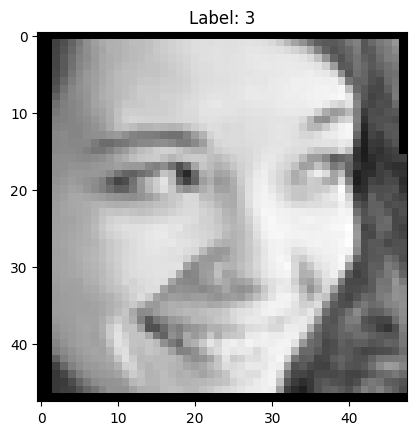

In [107]:
# Display an Example Image After Augmentation
images, labels = next(train_generator)
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {np.argmax(labels[0])}")
plt.show()

## Transfer Learning Model ( EfficientNetB0 )


***(Training output omitted here for brevity)***

In [4]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load EfficientNetB0 without top layers
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(48, 48, 3))

# Freeze base model (so only new layers train initially)
base_model.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Replaces Flatten()
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(num_classes, activation='softmax')(x)  # num_classes from train_generator.class_indices

# Create final model
model = Model(inputs=base_model.input, outputs=x)

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Show model summary
model.summary()

# Train only the top layers first
history = model.fit(train_generator, epochs=10, validation_data=val_generator, callbacks=callbacks)

# Unfreeze the base model and fine-tune everything
base_model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # Lower LR for fine-tuning
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Fine-tune the model
history_finetune = model.fit(train_generator, epochs=15, validation_data=val_generator, callbacks=callbacks)

# Evaluate Model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

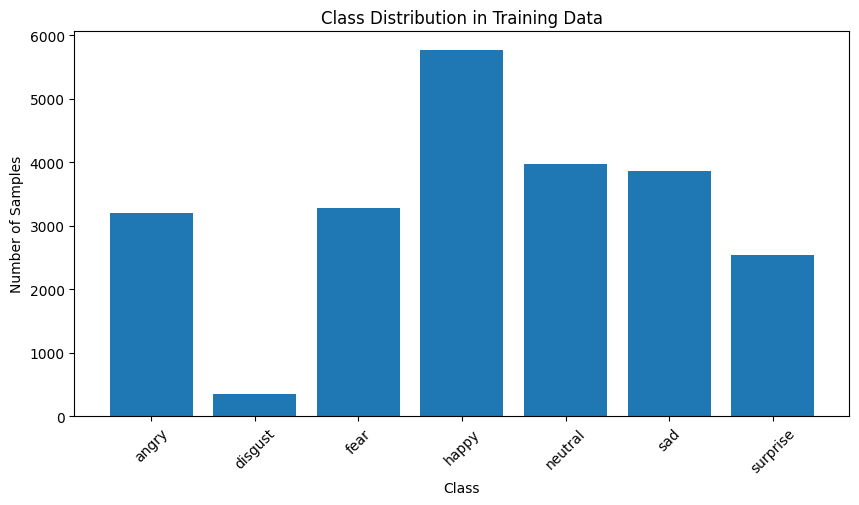

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Get class counts
class_counts = Counter(train_generator.classes)
class_labels = list(train_generator.class_indices.keys())

# Plot class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_labels, [class_counts[i] for i in range(len(class_labels))])
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Training Data")
plt.xticks(rotation=45)
plt.show()

## ResNet

***(Training output omitted here for brevity)***

Images need to be in RGB for ResNet

In [ ]:
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="rgb",  # Change from "grayscale" to "rgb"
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="rgb",  # Change from "grayscale" to "rgb"
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

test_generator = ImageDataGenerator(rescale=1.0/255).flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode="rgb",  # Change from "grayscale" to "rgb"
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [5]:
from tensorflow.keras.applications import ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(48, 48, 3))

# Freeze base model (so only new layers train initially)
base_model.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Replaces Flatten()
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(num_classes, activation='softmax')(x)  # num_classes from train_generator.class_indices

# Create final model
model = Model(inputs=base_model.input, outputs=x)

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Show model summary
model.summary()

# Train only the top layers first
history = model.fit(train_generator, epochs=10, validation_data=val_generator, callbacks=callbacks)

# Unfreeze the base model and fine-tune everything
base_model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # Lower LR for fine-tuning
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Fine-tune the model
history_finetune = model.fit(train_generator, epochs=15, validation_data=val_generator, callbacks=callbacks)

# Evaluate Model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

# **Final Model**

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class Labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


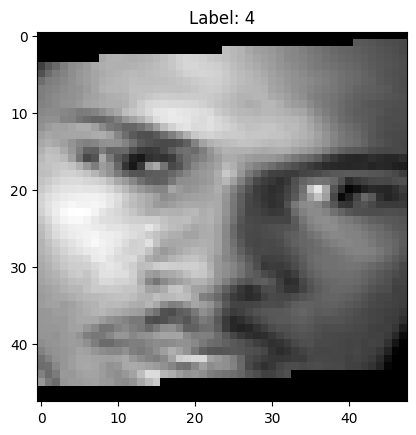

In [117]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

# Verify dataset exists
if not os.path.exists(train_dir) or not os.path.exists(test_dir):
    raise FileNotFoundError("Train or Test directory not found. Please check the dataset.")

# Define Training Data Generator (With Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=10,  # Reduced from 20
    width_shift_range=0.1,  # Reduced from 0.2
    height_shift_range=0.1,  # Reduced from 0.2
    zoom_range=0.2,
    shear_range=0.2,  # NEW: Perspective distortions
    # brightness_range=[0.8, 1.2],  # NEW: More varied lighting
    horizontal_flip=True,
    fill_mode='constant',  # Keep constant to avoid misleading artifacts
    validation_split=0.2
)

# Define Validation & Test Data Generator (Only Rescaling, No Augmentation)
val_test_datagen = ImageDataGenerator(rescale=1.0/255, validation_split=0.2)

# Load Images for Training
batch_size = 64
img_size = (48, 48)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

# Load Images for Validation (Using val_test_datagen to avoid augmentation)
val_generator = val_test_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

# Load Images for Testing (Using test_datagen)
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Print class labels
print("Class Labels:", train_generator.class_indices)

# Display Example Image
images, labels = next(train_generator)
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {np.argmax(labels[0])}")
plt.show()

Epoch 1/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.2036 - loss: 2.7611 - val_accuracy: 0.2541 - val_loss: 2.4495 - learning_rate: 3.0000e-04
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.2420 - loss: 2.4499 - val_accuracy: 0.2698 - val_loss: 2.4243 - learning_rate: 3.0000e-04
Epoch 3/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.3047 - loss: 2.2873 - val_accuracy: 0.3696 - val_loss: 2.1279 - learning_rate: 3.0000e-04
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.3530 - loss: 2.1566 - val_accuracy: 0.4369 - val_loss: 1.9483 - learning_rate: 3.0000e-04
Epoch 5/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.4021 - loss: 2.0351 - val_accuracy: 0.4719 - val_loss: 1.8574 - learning_rate: 3.0000e-04
Epoch 6/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.4414 - loss: 1.9163 - val_accuracy: 0.4748 - val_loss: 1.8003 - learning_rate: 3.0000e-04
Epoch 7/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/ste

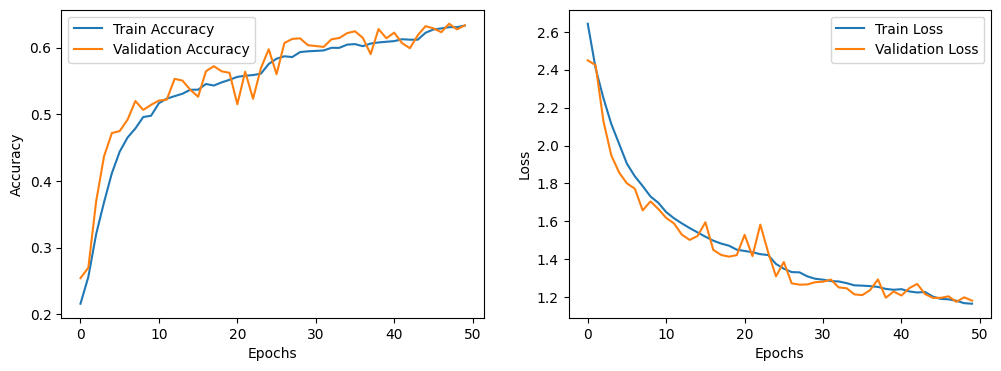

In [119]:
# Get the number of classes dynamically
num_classes = len(train_generator.class_indices)
# num_classes = len(sample_gen.class_indices)  # Use sample_gen which has class_indices

# Define the Improved CNN Model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48, 48, 1)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005), input_shape=(48, 48, 1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.AveragePooling2D(2, 2),  # Swapped one MaxPooling for AveragePooling
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.AveragePooling2D(2, 2),  # Added pooling after 512 conv layer
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Conv2D(512, (1, 1), activation='relu', kernel_regularizer=l2(0.0005)),  # Extra conv layer to extract final features
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.GlobalAveragePooling2D(),  # Replaces Flatten to reduce overfitting
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Compile Model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Early Stopping & Model Checkpoint
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint("fer_best_model.keras", save_best_only=True, save_freq='epoch'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)  # Adaptive Learning Rate
]

# Train model (Removed class weighting in favor of augmentation)
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks
)

# Evaluate Model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Final Analysis of Model

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
Overall Accuracy: 0.6414
              precision    recall  f1-score   support

       angry       0.54      0.59      0.57       958
     disgust       0.83      0.35      0.49       111
        fear       0.55      0.32      0.41      1024
       happy       0.86      0.86      0.86      1774
     neutral       0.50      0.78      0.61      1233
         sad       0.59      0.40      0.48      1247
    surprise       0.73      0.81      0.77       831

    accuracy                           0.64      7178
   macro avg       0.66      0.59      0.60      7178
weighted avg       0.65      0.64      0.63      7178



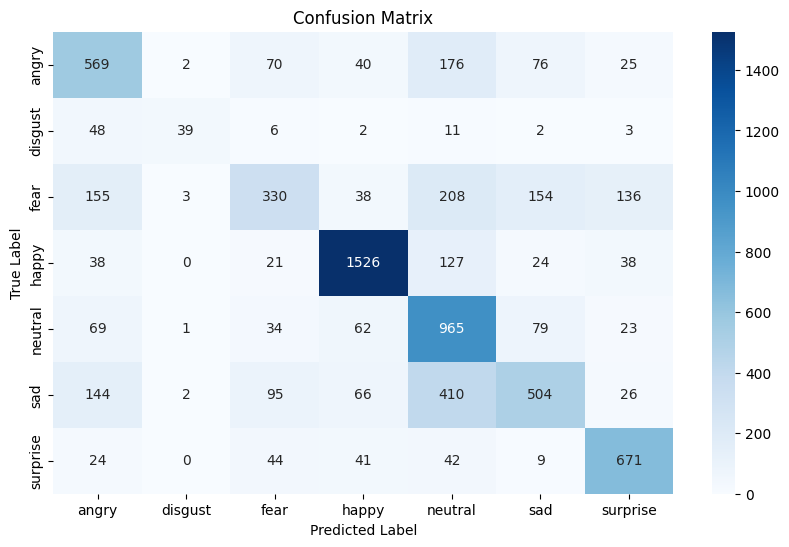

In [129]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Get true labels and predictions
y_true = test_generator.classes  # True labels
y_pred = model.predict(test_generator)  # Probabilities
y_pred_classes = y_pred.argmax(axis=1)  # Convert to class labels

# Compute accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Overall Accuracy: {accuracy:.4f}")  # Print overall accuracy

# Print classification report
print(classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [121]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5972 - loss: 1.2613
Test Accuracy: 0.6414


### **Brief Analysis**

- overall accuracy of the model is **64.14%**, indicating a moderate level of performance across the seven emotion classes.  
- **Happy (86%) and Surprise (73%)** were classified with high precision and recall, suggesting that these emotions are well-represented and easily distinguishable.  
- **Neutral (50% precision, 78% recall)** shows a strong recall, meaning many neutral faces are correctly classified, but some misclassifications occur.  
- **Fear (55% precision, 32% recall), Sad (59% precision, 40% recall), and Angry (54% precision, 59% recall)** struggled, particularly in recall, meaning these emotions are often confused with others.  
- **Disgust (83% precision, 35% recall)** had a **low recall**, meaning most disgusted faces were misclassified, likely due to the small sample size.  
- The **macro-average F1-score of 60%** suggests that performance varies across classes, with minority classes suffering more.  
- Overall, the model performs well on dominant emotions but may need further data balancing or fine-tuning for **fear, sad, and disgust** to improve recall.

### Next Steps  

To further improve performance, we could:  
- **Increase dataset size** for underrepresented classes.  
- **Implement focal loss** to prioritize hard-to-classify emotions.  
- **Explore additional architectures** with efficient scaling.  

Despite the challenges, our **custom CNN** demonstrated the best trade-off between accuracy, training time, and model complexity, making it the optimal choice for deployment.

----------

# Model Versioning and Information  

To ensure proper tracking of model iterations, we established a **model versioning system** that logs essential details such as **performance metrics, hyperparameters, and architecture choices**. Since AWS training resources were limited, models were trained **locally or on Google Colab’s A100 GPU** and then uploaded to **AWS S3 for version control**.  

### Key Steps in Model Versioning  

1. **Uploading Trained Models to S3**  
   - The best-performing model (`fer_best_model.h5`) was stored in an **S3 bucket** for future retrieval.  

2. **Creating a Model Package Group**  
   - We grouped our models under a **Model Package Group** in **AWS SageMaker**, which allows for version tracking.  

3. **Defining Model Metadata**  
   - Each version includes **model architecture, dataset details, training metrics, and hyperparameter configurations**.  

4. **Model Card Generation**  
   - We created a **model card** in AWS SageMaker, documenting critical details such as:  
     - **Model Objective**: Emotion recognition from facial images.  
     - **Training Dataset**: FER-2013 dataset.  
     - **Algorithm**: Custom CNN architecture.  
     - **Training Observations**: 35,000+ samples.  

### Importance of Model Versioning  

- **Facilitates Experiment Tracking**: Enables us to compare multiple architectures and fine-tune based on performance.  
- **Ensures Reproducibility**: Each model version is stored with metadata, allowing easy deployment or re-training if needed.  
- **Improves Model Management**: AWS **SageMaker Model Package Group** organizes models systematically, reducing redundancy.  

### Next Steps  

Moving forward, we can:  
- **Automate versioning**: Implement CI/CD pipelines to track future model updates automatically.  
- **Monitor model drift**: Store inference results alongside metadata to detect performance degradation.  
- **Integrate additional models**: Test alternative architectures and log improvements.  

This structured versioning approach ensures we maintain a clear historical record of our model iterations, making it easier to refine and deploy the best-performing versions.

In [5]:
import boto3
import os
import sagemaker
import pandas as pd 
import numpy as np 
import time

In [2]:
sess = sagemaker.Session()
bucket = sess.default_bucket()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
account_id = boto3.client("sts").get_caller_identity().get("Account")
 
sm = boto3.Session().client(service_name="sagemaker", region_name=region)

# Create s3 bucket for models
s3_model_path = 's3://{}/group-5/models'.format(bucket)
print(s3_model_path)

s3://sagemaker-us-east-1-399018723364/group-5/models


In [3]:
!aws s3 cp 'fer_best_model.h5' $s3_model_path/

upload: ./fer_best_model.h5 to s3://sagemaker-us-east-1-399018723364/group-5/models/fer_best_model.h5


In [6]:
sagemaker_client = boto3.client('sagemaker')
model_pacakge_group_name = "basic-cnn" + str(round(time.time()))
model_pacakge_group_description = ("Simple CNN model group for FER-2013 dataset")

# Create model package group
response = sagemaker_client.create_model_package_group(
    ModelPackageGroupName=model_pacakge_group_name,
    ModelPackageGroupDescription=model_pacakge_group_description
)

print(f"Creation of Model Package Group: {response}")

Creation of Model Package Group: {'ModelPackageGroupArn': 'arn:aws:sagemaker:us-east-1:399018723364:model-package-group/basic-cnn1738537479', 'ResponseMetadata': {'RequestId': '9ac1961e-65d7-4325-89db-aff845cbccd7', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': '9ac1961e-65d7-4325-89db-aff845cbccd7', 'content-type': 'application/x-amz-json-1.1', 'content-length': '107', 'date': 'Sun, 02 Feb 2025 23:04:38 GMT'}, 'RetryAttempts': 0}}


In [10]:
!aws ecr list-images --region us-east-1


usage: aws [options] <command> <subcommand> [<subcommand> ...] [parameters]
To see help text, you can run:

  aws help
  aws <command> help
  aws <command> <subcommand> help

aws: error: the following arguments are required: --repository-name



In [15]:
# Define model and version info
s3_model_path = f's3://sagemaker-us-east-1-399018723364/group-5/models/fer_best_model.h5'
# Create model package for versioning
model_package_name = 'v1-basic-fer-cnn'
## FIXME Find the right image to use, don't want xgboost, want tensorflow but everything was giving access denied
container_image_uri = "811284229777.dkr.ecr.us-east-1.amazonaws.com/xgboost:1"
model_package_response = sagemaker_client.create_model_package(
    ModelPackageName=model_package_name,
    ModelPackageDescription="Version 1 of CNN model",
    InferenceSpecification={
    "Containers": [
        {
            "Image": container_image_uri,
            "ModelDataUrl": s3_model_path,
        }
    ],
    "SupportedContentTypes": ["text/csv"],
    "SupportedResponseMIMETypes": ["text/csv"],
    "SupportedTransformInstanceTypes": ['ml.m4.xlarge'],
    "SupportedRealtimeInferenceInstanceTypes": ['ml.t2.xlarge']
    }
)
print(model_package_response)

{'ModelPackageArn': 'arn:aws:sagemaker:us-east-1:399018723364:model-package/v1-basic-fer-cnn', 'ResponseMetadata': {'RequestId': '03feab7f-3917-440a-96a7-93d8f7b551bd', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': '03feab7f-3917-440a-96a7-93d8f7b551bd', 'content-type': 'application/x-amz-json-1.1', 'content-length': '93', 'date': 'Sun, 02 Feb 2025 23:25:00 GMT'}, 'RetryAttempts': 0}}


In [16]:
# Describe Model Package
describe_model_pacakge_response = sagemaker_client.describe_model_package(
    ModelPackageName=model_package_name
)

print(f"Model Package Details: {describe_model_pacakge_response}")

Model Package Details: {'ModelPackageName': 'v1-basic-fer-cnn', 'ModelPackageArn': 'arn:aws:sagemaker:us-east-1:399018723364:model-package/v1-basic-fer-cnn', 'ModelPackageDescription': 'Version 1 of CNN model', 'CreationTime': datetime.datetime(2025, 2, 2, 23, 25, 0, 251000, tzinfo=tzlocal()), 'InferenceSpecification': {'Containers': [{'Image': '811284229777.dkr.ecr.us-east-1.amazonaws.com/xgboost:1', 'ImageDigest': 'sha256:0c8f830ac408e6dee08445fb60392e9c3f05f790a4b3c07ec22327c08f75bcbf', 'ModelDataUrl': 's3://sagemaker-us-east-1-399018723364/group-5/models/fer_best_model.h5'}], 'SupportedTransformInstanceTypes': ['ml.m4.xlarge'], 'SupportedRealtimeInferenceInstanceTypes': ['ml.t2.xlarge'], 'SupportedContentTypes': ['text/csv'], 'SupportedResponseMIMETypes': ['text/csv']}, 'ModelPackageStatus': 'Completed', 'ModelPackageStatusDetails': {'ValidationStatuses': [], 'ImageScanStatuses': []}, 'CertifyForMarketplace': False, 'CreatedBy': {'UserProfileArn': 'arn:aws:sagemaker:us-east-1:39901

In [18]:
import json
model_content = {
    "model_overview": {
        "model_description": "Basic CNN model",
        "model_creator": "Group 5",
        "model_artifact": [s3_model_path],
        "algorithm_type": "CNN",
    },
    "training_details": {
        "objective_function": "identify malignent masses given input data",
        "training_observations": "35000",
    },
}
response = sagemaker_client.create_model_card(
    ModelCardName="basic-cnn-model-card",
    Content=json.dumps(model_content),
    ModelCardStatus='Draft',
)

print(f"Model card created: {response}")

Model card created: {'ModelCardArn': 'arn:aws:sagemaker:us-east-1:399018723364:model-card/basic-cnn-model-card', 'ResponseMetadata': {'RequestId': 'a20db295-b1b5-44c3-96c6-bc955fdbf998', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': 'a20db295-b1b5-44c3-96c6-bc955fdbf998', 'content-type': 'application/x-amz-json-1.1', 'content-length': '91', 'date': 'Sun, 02 Feb 2025 23:28:26 GMT'}, 'RetryAttempts': 0}}


In [19]:
# Describe Model Card (for submission screenshot)
describe_model_card_response = sagemaker_client.describe_model_card(
    ModelCardName="basic-cnn-model-card"
)
print("Model Card Details:", describe_model_card_response)

Model Card Details: {'ModelCardArn': 'arn:aws:sagemaker:us-east-1:399018723364:model-card/basic-cnn-model-card', 'ModelCardName': 'basic-cnn-model-card', 'ModelCardVersion': 1, 'Content': '{"model_overview": {"model_description": "Basic CNN model", "model_creator": "Group 5", "model_artifact": ["s3://sagemaker-us-east-1-399018723364/group-5/models/fer_best_model.h5"], "algorithm_type": "CNN"}, "training_details": {"objective_function": "identify malignent masses given input data", "training_observations": "35000"}}', 'ModelCardStatus': 'Draft', 'CreationTime': datetime.datetime(2025, 2, 2, 23, 28, 26, 621000, tzinfo=tzlocal()), 'CreatedBy': {'UserProfileArn': 'arn:aws:sagemaker:us-east-1:399018723364:user-profile/d-coj0j6t5xpww/kvierczhalek', 'UserProfileName': 'kvierczhalek', 'DomainId': 'd-coj0j6t5xpww'}, 'LastModifiedTime': datetime.datetime(2025, 2, 2, 23, 28, 26, 621000, tzinfo=tzlocal()), 'LastModifiedBy': {'UserProfileArn': 'arn:aws:sagemaker:us-east-1:399018723364:user-profile/

----------

In [ ]:
## CI/CD Pipeline for Model Deployment  

To streamline model deployment and versioning, we implemented a **CI/CD pipeline** that automates the integration of **pre-trained models** into an **AWS SageMaker environment**. Due to computational constraints in AWS, training occurs **outside the pipeline** on **Google Colab’s A100 GPU**, and the resulting **H5 model artifact** is uploaded to **AWS S3** for further processing.  

### **Pipeline Stages**  

1. **Model Evaluation**  
   - The pipeline starts by evaluating the uploaded model’s performance using predefined metrics.  
   - Evaluation results (accuracy, precision, recall) are stored as an **evaluation.json** file in S3 for tracking.  

2. **Model Registration**  
   - The trained model is registered in **AWS SageMaker Model Registry**, ensuring version control and structured management.  
   - A **Model Package Group** is created to store different iterations of our model.  

3. **Model Deployment**  
   - A **SageMaker Model Endpoint** is created for real-time inference.  
   - Model metadata, including **hyperparameters, instance configurations, and performance metrics**, is logged.  

4. **CI/CD Automation with GitHub Actions**  
   - Whenever a new model is trained and pushed to the repository, GitHub Actions trigger the pipeline.  
   - The pipeline detects changes, uploads the **new model artifact to S3**, and deploys it for inference.  

### **Key Benefits of this Approach**  

- **Efficient Resource Utilization**:  
  - Avoids excessive AWS costs by running training on external GPUs.  
  - Uses AWS SageMaker only for **evaluation, registration, and deployment**.  

- **Seamless Model Updates**:  
  - New models are automatically integrated into production, with **version tracking**.  
  - Maintainers receive notifications when a new model is available.  

- **Scalable and Reproducible**:  
  - Pipeline ensures **consistent model validation** before deployment.  
  - **Parameterized execution** allows flexibility in instance type, dataset location, and accuracy thresholds.  

### **Next Steps**  

- **Enhance Automated Model Selection**: Incorporate a mechanism that **selects the best-performing model** based on predefined accuracy thresholds.  
- **Expand Monitoring Capabilities**: Implement **drift detection** to track performance changes over time.  
- **Optimize Deployment Costs**: Explore lightweight **serverless inference options (AWS Lambda, SageMaker Serverless)** to reduce endpoint costs.  

This pipeline provides a **scalable, automated workflow** for deploying emotion recognition models while maintaining efficiency and cost-effectiveness.

# Pipeline
This notebook creates a CI/CD pipeline that runs the full MLOps system. Due to some limitations with resource limitability in AWS as well as permissions, this pipeline will take a pretrained model in instead of training as part of the pipeline. Since the problem is a computer vision problem, the training takes much longer and uses too many AWS resources. In order to adjust for this, the model is trained within a CI/CD action in Github. When changes are made to the model, or a new model is tested, the pipeline will run and create an h5 artifact and notify the maintainers that a new artifact exists. This h5 file is uploaded to an S3 bucket (outside of this notebook) and then used in the remaining processing steps. Stages in the pipeline are:
1. Determine Metrics

In [41]:
# Setup steps
import sys

import boto3
import sagemaker
from sagemaker.workflow.pipeline_context import PipelineSession

sess = sagemaker.Session()
bucket = sess.default_bucket()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
account_id = boto3.client("sts").get_caller_identity().get("Account")
sm_client = boto3.client('sagemaker')
pipeline_session = PipelineSession()
model_package_group_name = f"FERModelGroupName"

### Define Parameters for Pipeline Execution
Define the Pipeline parameters that are used for this pipeline. This enables custom pipeline executions without having to modify the pipeline definition. The parameters defined in this workflow are:
- `processing_instance_count` - The instance count of the processing job
- `instance_type` - The `ml.*` instance type of the training job
- `model_approval_status` - The approval status to register with the trained model for CI/CD purposes (Defaults to "PendingManualApproval")
- `accuracy_threshold` - The accuracy threshold used to verify the accuracy of the model, initially set to >50%
- `s3_bucket` - The name of the s3 bucket that holds the data
- `s3_test_data_prefix` - Prefix of the directory that holds the test data (used in evaluation)
- `s3_model_prefix` - Where to find the model in s3

In [42]:
from sagemaker.workflow.parameters import (
    ParameterInteger,
    ParameterString,
    ParameterFloat,
)

processing_instance_count = ParameterInteger(name="ProcessingInstanceCount", default_value=1)
instance_type = ParameterString(name="TrainingInstanceType", default_value="ml.m5.xlarge")
model_approval_status = ParameterString(
    name="ModelApprovalStatus", default_value="PendingManualApproval"
)
accuracy_threshold = ParameterFloat(name="AccuracyThreshold", default_value=0.5)
s3_bucket = ParameterString(name="S3Bucket", default_value="sagemaker-us-east-1-399018723364")
s3_test_data_prefix = ParameterString(name="S3TestDataPrefix", default_value="test/test/")
s3_model_prefix = ParameterString(name="S3ModelPrefix", default_value="group-5/models/")


### Define Model Evaluation Step 
This step evaluates the pre-trained model. This is a custom evaluation script that will preform the model evaluation. After the pipeline runs, the resulting `evaluation.json` file will be available for further analysis. 

### Register Model
A model package is an abstraction of reusable model artifacts that packages all the ingredients required for inference. Primarily, it consistes of an inference specification that defines the inference image to use along with an option model weights location.

A model package group is a collection of model packages. A model package group can be created for a specific ML business problem, and new versions of the model packages can be added to it. Typically, customers are expected to create a ModelPackageGroup for a SageMaker pipeline so that model package versions can be added to the group for every SageMaker pipeline run.

In [43]:
from sagemaker.model import Model

model_data = f's3://{bucket}/group-5/models/model.tar.gz'

image_uri = sagemaker.image_uris.retrieve(
        framework="pytorch",
        region=region,
        version="1.10.0",
        image_scope="inference",
        instance_type="ml.m5.xlarge"
    )

model = Model(
    image_uri=image_uri,
    model_data=model_data,
    sagemaker_session=pipeline_session,
    role=role,
)

INFO:sagemaker.image_uris:Defaulting to only available Python version: py38


In [45]:
import json
# Get Model Metrics from S3
s3_model_metrics = f's3://{bucket}/group-5/metrics/metrics.json'

# s3_client = boto3.client("s3")
# s3_client.download_file(s3_model_metrics)

# with open("metrics.json", "r") as f:
#     metrics_data = json.load(f)



In [46]:
from sagemaker.model_metrics import MetricsSource, ModelMetrics
from sagemaker.workflow.model_step import ModelStep
from sagemaker.workflow.parameters import ParameterString

# accuracy = metrics_data.get("Accuracy", 0.0)

model_metrics = ModelMetrics(
    model_statistics=MetricsSource(
        s3_uri=s3_model_metrics,
        content_type="application/json"
    )
)

model_package_arn_param = ParameterString(name="ModelPackageArn")

register_args = model.register(
    content_types=["text/csv"],
    response_types=["text/csv"],
    inference_instances=["ml.t2.medium", "ml.m5.xlarge"],
    transform_instances=["ml.m5.xlarge"],
    model_package_group_name=model_package_group_name,
    approval_status=model_approval_status,
    model_metrics=model_metrics
)
step_register = ModelStep(name="FERRegisterModel", step_args=register_args)


/opt/conda/lib/python3.11/site-packages/sagemaker/workflow/pipeline_context.py:332: UserWarning: Running within a PipelineSession, there will be No Wait, No Logs, and No Job being started.
  warnings.warn(


## Step to Create Endpoint
This step will create a model endpoint now that the model has been registered. 

In [47]:
from datetime import datetime
from sagemaker.workflow.model_step import ModelStep
from sagemaker.workflow.steps import CreateModelStep, ProcessingStep
from sagemaker.processing import ScriptProcessor, ProcessingInput, ProcessingOutput
from sagemaker.workflow.parameters import ParameterString

# Create the Model in SageMaker
step_create_model = CreateModelStep(
    name="CreateSageMakerModel",
    model=model,
)


### Define a pipeline of parameters, steps and conditions
In this section, the steps defined above are combined into a Pipeline so it can be executed.

A pipeline requires a `name`, `parameters`, and `steps`. 

In [48]:
from sagemaker.workflow.pipeline import Pipeline


pipeline_name = f"FERPipeline-WithEndpoint"
pipeline = Pipeline(
    name=pipeline_name,
    parameters=[
        processing_instance_count,
        instance_type,
        model_approval_status
    ],
    steps=[step_register, step_create_model]
)

print(pipeline.steps)

[ModelStep(name='FERRegisterModel', steps=[<sagemaker.workflow._utils._RegisterModelStep object at 0x7fefce359790>], depends_on=None), <sagemaker.workflow.steps.CreateModelStep object at 0x7fefd7c55350>]


In [35]:
# Check pipeline definition
import json


definition = json.loads(pipeline.definition())
definition

{'Version': '2020-12-01',
 'Metadata': {},
 'Parameters': [{'Name': 'ProcessingInstanceCount',
   'Type': 'Integer',
   'DefaultValue': 1},
  {'Name': 'TrainingInstanceType',
   'Type': 'String',
   'DefaultValue': 'ml.m5.xlarge'},
  {'Name': 'ModelApprovalStatus',
   'Type': 'String',
   'DefaultValue': 'PendingManualApproval'}],
 'PipelineExperimentConfig': {'ExperimentName': {'Get': 'Execution.PipelineName'},
  'TrialName': {'Get': 'Execution.PipelineExecutionId'}},
 'Steps': [{'Name': 'FERRegisterModel-RegisterModel',
   'Type': 'RegisterModel',
   'Arguments': {'ModelPackageGroupName': 'FERModelGroupName',
    'InferenceSpecification': {'Containers': [{'Image': '763104351884.dkr.ecr.us-east-1.amazonaws.com/pytorch-inference:1.10.0-cpu-py38',
       'Environment': {},
       'ModelDataUrl': 's3://sagemaker-us-east-1-399018723364/group-5/models/model.tar.gz'}],
     'SupportedContentTypes': ['text/csv'],
     'SupportedResponseMIMETypes': ['text/csv'],
     'SupportedRealtimeInferen

### Submit pipeline to SageMaker and Execute
Submit the pipeline definition to the Pipeline service. The Pipeline service uses the role that is passed in to create all the jobs defined in the steps.

In [49]:
pipeline.upsert(role_arn=role)


{'PipelineArn': 'arn:aws:sagemaker:us-east-1:399018723364:pipeline/FERPipeline-WithEndpoint',
 'ResponseMetadata': {'RequestId': '0ccaf6db-9672-4f05-b48e-22675f5a3b6d',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '0ccaf6db-9672-4f05-b48e-22675f5a3b6d',
   'content-type': 'application/x-amz-json-1.1',
   'content-length': '92',
   'date': 'Sun, 23 Feb 2025 20:14:57 GMT'},
  'RetryAttempts': 0}}

In [50]:
# Start the pipeline and accept all the default parameters
execution = pipeline.start()

### Pipeline Operations: Examining and waiting for pipeline execution
Describe the pipeline and examing the execution

In [38]:
execution.describe()

{'PipelineArn': 'arn:aws:sagemaker:us-east-1:399018723364:pipeline/FERPipeline-WithEndpoint',
 'PipelineExecutionArn': 'arn:aws:sagemaker:us-east-1:399018723364:pipeline/FERPipeline-WithEndpoint/execution/lw8v9yw16u5k',
 'PipelineExecutionDisplayName': 'execution-1740338237833',
 'PipelineExecutionStatus': 'Succeeded',
 'PipelineExperimentConfig': {'ExperimentName': 'ferpipeline-withendpoint',
  'TrialName': 'lw8v9yw16u5k'},
 'CreationTime': datetime.datetime(2025, 2, 23, 19, 17, 17, 739000, tzinfo=tzlocal()),
 'LastModifiedTime': datetime.datetime(2025, 2, 23, 19, 17, 20, 710000, tzinfo=tzlocal()),
 'CreatedBy': {'UserProfileArn': 'arn:aws:sagemaker:us-east-1:399018723364:user-profile/d-coj0j6t5xpww/kvierczhalek',
  'UserProfileName': 'kvierczhalek',
  'DomainId': 'd-coj0j6t5xpww',
  'IamIdentity': {'Arn': 'arn:aws:sts::399018723364:assumed-role/LabRole/SageMaker',
   'PrincipalId': 'AROAVZZ26RASKWFFRC3N6:SageMaker'}},
 'LastModifiedBy': {'UserProfileArn': 'arn:aws:sagemaker:us-east-1

In [39]:
execution.wait()

In [40]:
# Shows which steps have been executed
execution.list_steps()

[{'StepName': 'CreateSageMakerModel',
  'StartTime': datetime.datetime(2025, 2, 23, 19, 17, 19, 5000, tzinfo=tzlocal()),
  'EndTime': datetime.datetime(2025, 2, 23, 19, 17, 20, 432000, tzinfo=tzlocal()),
  'StepStatus': 'Succeeded',
  'Metadata': {'Model': {'Arn': 'arn:aws:sagemaker:us-east-1:399018723364:model/pipelines-lw8v9yw16u5k-CreateSageMakerModel-qEHP3QSb4A'}},
  'AttemptCount': 1},
 {'StepName': 'FERRegisterModel-RegisterModel',
  'StartTime': datetime.datetime(2025, 2, 23, 19, 17, 19, 5000, tzinfo=tzlocal()),
  'EndTime': datetime.datetime(2025, 2, 23, 19, 17, 20, 132000, tzinfo=tzlocal()),
  'StepStatus': 'Succeeded',
  'Metadata': {'RegisterModel': {'Arn': 'arn:aws:sagemaker:us-east-1:399018723364:model-package/FERModelGroupName/22'}},
  'AttemptCount': 1}]

----------

# Data Monitor

In [ ]:
import argparse
import boto3
import sagemaker
from datetime import datetime
from sagemaker.model_monitor import DataCaptureConfig
from sagemaker.model import Model

# importing monitor requirments:
from sagemaker.model_monitor import (
    DataCaptureConfig,
    DataQualityMonitor,
    DatasetFormat,
    MonitoringOutput,
    MonitoringOutputConfig,
    MonitoringOutput,
)

from sagemaker.processing import ProcessingInput, ProcessingOutput

# Parse command-line arguments
parser = argparse.ArgumentParser()
parser.add_argument("--model_s3_path", type=str, required=True)  # Model artifact location in S3
parser.add_argument("--s3_capture_upload_path", type=str, required=True)  # Data capture path in S3
parser.add_argument("--region", type=str, required=True) # Region
args = parser.parse_args()

# Define Model Artifact & Data Capture Path
model_s3_path = args.model_s3_path
s3_capture_upload_path = args.s3_capture_upload_path
region = args.region

# Setup session
boto3.setup_default_session(region_name=region)
sagemaker_session = sagemaker.Session()

# Generate Endpoint Name
endpoint_name = f"FER-Image-Model-{datetime.utcnow():%Y-%m-%d-%H%M}"
print(f"Deploying model to endpoint: {endpoint_name}")

# Initialize SageMaker Session & Role
# sagemaker_session = sagemaker.Session()
role = sagemaker.get_execution_role()

# Configure Data Capture
data_capture_config = DataCaptureConfig(
    enable_capture=True,
    sampling_percentage=100,
    destination_s3_uri=s3_capture_upload_path
)

# Define the Model for Deployment
model = Model(
    model_data=model_s3_path,  # ✅ Load model from S3
    role=role,
    sagemaker_session=sagemaker_session
)

# Deploy the Model to an Endpoint 
# added the predictor variable 
predictor = model.deploy(
    initial_instance_count=1,
    instance_type="ml.m4.xlarge",
    endpoint_name=endpoint_name,
    data_capture_config=data_capture_config
)

print(f"Model successfully deployed to endpoint: {endpoint_name}")

In [ ]:
# Creating a data quality monitor for Baseline and Schedule 

data_quality_monitor = DataQualityMonitor(
    role = role,
    instance_count = 1,
    instance_type ="ml.m5.xlarge",
    volume_size_in_gb =30,
    max_runtime_in_seconds = 3600,
    base_job_name = "face-express-class-dist-baseline-job", 
    sagemaker_session = sagemaker_session

)

In [ ]:
print("Running baseline job...")
data_quality_monitor.run_baseline(
    dataset_format = DatasetFormat.csv(header=False), 
    baseline_inputs = [
        ProcessingInput(
            source=baseline_dataset_s3_path_placeholder,  # We'll need to edit this to the right path.
            destination="/opt/ml/processing/input/data"
        )
    ],
    output = ProcessingOutput(
        source="/opt/ml/processing/output",
        destination = baseline_results_s3_path_placeholder  
    ),
    wait = True,
    logs = True
)

print(f"Baseline job completed. Baseline outputs stored at: {baseline_results_s3_path_placeholder}")

In [ ]:
# Statistics JSON & Constraints files

baseline_statistics_uri = f"{baseline_results_s3_path_placeholder }/statistics.json"
baseline_constraints_uri = f"{baseline_results_s3_path_placeholder }/constraints.json"

In [ ]:
# Creating a monitoring schedule:
 
monitoring_schedule_name = "cv-class-dist-monitor-schedule"
monitoring_output_uri = f"{baseline_results_s3_path_placeholder}/monitoring-output"  

print(f"Creating monitoring schedule: {monitoring_schedule_name}")

data_quality_monitor.create_monitoring_schedule(
    monitor_schedule_name=monitoring_schedule_name,
    endpoint_input=endpoint_name,
    output_s3_uri=monitoring_output_uri,
    statistics=baseline_statistics_uri,
    constraints=baseline_constraints_uri,
    schedule_cron_expression="cron(0 * ? * * *)",  # Runs every hour. Adjust as needed.
    enable_cloudwatch_metrics=True
)

print(f"Monitoring schedule '{monitoring_schedule_name}' created.")
print(f"Monitoring output will be stored in: {monitoring_output_uri}")

In [ ]:
print("Data drift monitoring for class distribution has been set up successfully.")
print("SageMaker Model Monitor will compare the predicted classes in production")
print("to the baseline distribution and raise alerts if drift occurs.")

In [110]:
import os
import zipfile
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import smart_resize
from tensorflow.keras.utils import to_categorical
from PIL import Image

In [2]:
import kagglehub
path = kagglehub.dataset_download("msambare/fer2013")

----------

----------

----------

# Extra

## Simple CNN Model

# Model Versioning And Information
This notebook is intended to track the model versions. This includes metrics on model performance, hyperparameters, algorithms used, and any additional information related to the training model. Due to limited resources in AWS, the models are not trained within AWS and are instead trained on local hardward. The information for the Model groups are generated from uploaded h5 files. 

In [3]:
# Set paths
base_dir = "/Users/danielarday/.cache/kagglehub/datasets/msambare/fer2013/versions/1"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

In [21]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_true), y=y_true)
class_weights = dict(enumerate(class_weights))

NameError: name 'y_true' is not defined

In [2]:
import boto3
import os
import sagemaker
import pandas as pd 
import numpy as np 
import tensorflow as tf
import json
from sagemaker.model import Model

In [11]:
!pip install -U sagemaker

  Using cached sagemaker_core-1.0.22-py3-none-any.whl.metadata (4.9 kB)
  Using cached s3transfer-0.11.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached mock-4.0.3-py3-none-any.whl.metadata (2.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.1 MB/s eta 0:00:00
Using cached sagemaker_core-1.0.22-py3-none-any.whl (404 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 115.7 MB/s eta 0:00:00
Using cached mock-4.0.3-py3-none-any.whl (28 kB)
Using cached s3transfer-0.11.2-py3-none-any.whl (84 kB)
  Attempting uninstall: mock
    Found existing installation: mock 5.1.0
    Uninstalling mock-5.1.0:
      Successfully uninstalled mock-5.1.0
  Attempting uninstall: botocore
    Found existing installation: botocore 1.34.162
    Uninstalling botocore-1.34.162:
      Successfully uninstalled botocore-1.34.162
  Attempting uninstall: s3transfer
    Found existing installation: s3transfer 0.10.4
    Uninstalling s3transfer-0.10.4:
      Successfully uninstalled s3transfer

Images need to be in RGB for ResNet

In [33]:
from tensorflow.keras.applications import ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(48, 48, 3))

# Freeze base model (so only new layers train initially)
base_model.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Replaces Flatten()
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(num_classes, activation='softmax')(x)  # num_classes from train_generator.class_indices

# Create final model
model = Model(inputs=base_model.input, outputs=x)

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Show model summary
model.summary()

# Train only the top layers first
history = model.fit(train_generator, epochs=10, validation_data=val_generator, callbacks=callbacks)

# Unfreeze the base model and fine-tune everything
base_model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # Lower LR for fine-tuning
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Fine-tune the model
history_finetune = model.fit(train_generator, epochs=15, validation_data=val_generator, callbacks=callbacks)

# Evaluate Model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 48, 48, 3)]          0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 54, 54, 3)            0         ['input_3[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 24, 24, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 24, 24, 64)           256       ['conv1_conv[0][0]']          
 on)                                                                                        

                                                                                                  
 conv2_block3_1_conv (Conv2  (None, 12, 12, 64)           16448     ['conv2_block2_out[0][0]']    
 D)                                                                                               
                                                                                                  
 conv2_block3_1_bn (BatchNo  (None, 12, 12, 64)           256       ['conv2_block3_1_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv2_block3_1_relu (Activ  (None, 12, 12, 64)           0         ['conv2_block3_1_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv2_blo

 ation)                                                                                           
                                                                                                  
 conv3_block2_3_conv (Conv2  (None, 6, 6, 512)            66048     ['conv3_block2_2_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv3_block2_3_bn (BatchNo  (None, 6, 6, 512)            2048      ['conv3_block2_3_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv3_block2_add (Add)      (None, 6, 6, 512)            0         ['conv3_block1_out[0][0]',    
                                                                     'conv3_block2_3_bn[0][0]']   
          

 conv4_block1_2_conv (Conv2  (None, 3, 3, 256)            590080    ['conv4_block1_1_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv4_block1_2_bn (BatchNo  (None, 3, 3, 256)            1024      ['conv4_block1_2_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_block1_2_relu (Activ  (None, 3, 3, 256)            0         ['conv4_block1_2_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv4_block1_0_conv (Conv2  (None, 3, 3, 1024)           525312    ['conv3_block4_out[0][0]']    
 D)       

                                                                                                  
 conv4_block3_out (Activati  (None, 3, 3, 1024)           0         ['conv4_block3_add[0][0]']    
 on)                                                                                              
                                                                                                  
 conv4_block4_1_conv (Conv2  (None, 3, 3, 256)            262400    ['conv4_block3_out[0][0]']    
 D)                                                                                               
                                                                                                  
 conv4_block4_1_bn (BatchNo  (None, 3, 3, 256)            1024      ['conv4_block4_1_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_blo

 D)                                                                                               
                                                                                                  
 conv4_block6_3_bn (BatchNo  (None, 3, 3, 1024)           4096      ['conv4_block6_3_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_block6_add (Add)      (None, 3, 3, 1024)           0         ['conv4_block5_out[0][0]',    
                                                                     'conv4_block6_3_bn[0][0]']   
                                                                                                  
 conv4_block6_out (Activati  (None, 3, 3, 1024)           0         ['conv4_block6_add[0][0]']    
 on)                                                                                              
          

 conv5_block3_1_relu (Activ  (None, 2, 2, 512)            0         ['conv5_block3_1_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv5_block3_2_conv (Conv2  (None, 2, 2, 512)            2359808   ['conv5_block3_1_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv5_block3_2_bn (BatchNo  (None, 2, 2, 512)            2048      ['conv5_block3_2_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv5_block3_2_relu (Activ  (None, 2, 2, 512)            0         ['conv5_block3_2_bn[0][0]']   
 ation)   

/opt/anaconda3/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


359/359 [==============================] - 532s 1s/step - loss: 1.1753 - accuracy: 0.5569 - val_loss: 1.2150 - val_accuracy: 0.5348
Epoch 7/15
359/359 [==============================] - 529s 1s/step - loss: 1.1379 - accuracy: 0.5715 - val_loss: 1.2011 - val_accuracy: 0.5424
Epoch 8/15
359/359 [==============================] - 533s 1s/step - loss: 1.1062 - accuracy: 0.5814 - val_loss: 1.1741 - val_accuracy: 0.5574
Epoch 9/15
359/359 [==============================] - 530s 1s/step - loss: 1.0935 - accuracy: 0.5882 - val_loss: 1.1758 - val_accuracy: 0.5569
Epoch 10/15
359/359 [==============================] - 535s 1s/step - loss: 1.0580 - accuracy: 0.6041 - val_loss: 1.2284 - val_accuracy: 0.5569
Epoch 11/15
359/359 [==============================] - 537s 1s/step - loss: 1.0413 - accuracy: 0.6102 - val_loss: 1.1369 - val_accuracy: 0.5799
Epoch 12/15
359/359 [==============================] - 19329s 54s/step - loss: 1.0135 - accuracy: 0.6210 - val_loss: 1.1776 - val_accuracy: 0.5720
Epoc

In [4]:
# Create Model Package Group (if not exists)
try:
    sagemaker_client.create_model_package_group(
        ModelPackageGroupName=model_package_group_name,
        ModelPackageGroupDescription="Model Group for FER2013 Emotion Detection"
    )
    print(f"Model package group '{model_package_group_name}' created.")
except sagemaker_client.exceptions.ResourceInUseException:
    print(f"Model package group '{model_package_group_name}' already exists.")

Model package group 'FER2013-Model-Group' created.


In [7]:
# Upload model to S3
s3_client.upload_file("fer_best_model.keras", bucket, "models/model.keras")
print(f"Model uploaded to {model_s3_path}")

Model uploaded to s3://sagemaker-us-east-1-399018723364/models/model.keras


Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class Labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


Text(0.5, 1.0, 'Label: 3')

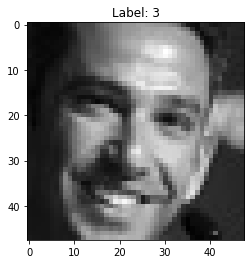

In [145]:
# Define ImageDataGenerator for preprocessing
datagen = ImageDataGenerator(
    rescale=1.0/255,  
#     rotation_range=20,  
#     width_shift_range=0.2,
#     height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='constant',
    validation_split=0.2  # Splitting train into train/validation
)

# Load images using ImageDataGenerator
batch_size = 64
img_size = (48, 48)

# Load images from directories
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

test_generator = ImageDataGenerator(rescale=1.0/255).flow_from_directory(
    test_dir,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Print class labels
print("Class Labels:", train_generator.class_indices)

# Example: Get a batch of images
images, labels = next(train_generator)
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {np.argmax(labels[0])}")


In [6]:
sagemaker_session = sagemaker.Session()
bucket = sagemaker_session.default_bucket()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
account_id = boto3.client("sts").get_caller_identity().get("Account")
 
s3_client = boto3.client(service_name="s3", region_name=region)
sagemaker_client = boto3.client("sagemaker", region_name=region)
model_package_group_name = "FER2013-Model-Group"

# Define S3 path for the model
model_s3_path = f"s3://{bucket}/models/model.keras"

In [32]:
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="rgb",  # Change from "grayscale" to "rgb"
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="rgb",  # Change from "grayscale" to "rgb"
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

test_generator = ImageDataGenerator(rescale=1.0/255).flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode="rgb",  # Change from "grayscale" to "rgb"
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [8]:
# Load model to extract metadata
model = tf.keras.models.load_model("fer_best_model.keras")
config = model.get_config()
optimizer_config = model.optimizer.get_config()

In [9]:
# Extract hyperparameters and model details
model_metadata = {
    "Algorithm": "Convolutional Neural Network (CNN)",
    "Framework": "TensorFlow",
    "Hyperparameters": {
        "optimizer": model.optimizer.__class__.__name__,
        "learning_rate": optimizer_config.get("learning_rate", "Unknown"),
        "batch_size": "Unknown",  # Batch size is usually set during training
        "epochs": "Unknown"  # Epochs are not stored in the model file
    },
    "Architecture": [layer["class_name"] for layer in config["layers"]],
    "Loss Function": model.loss,
}


In [16]:
# Register Model Package
response = sagemaker_client.create_model_package(
    ModelPackageGroupName=model_package_group_name,
    ModelPackageDescription="FER2013 Emotion Detection Model",
    InferenceSpecification={
        "Containers": [
            {
                "Image": sagemaker.image_uris.retrieve(
                    framework="tensorflow",
                    region=region,
                    version="2.8",
                    instance_type="ml.m5.large",
                    image_scope="inference"
                ),
                "ModelDataUrl": model_s3_path,
            }
        ],
        "SupportedContentTypes": ["application/x-npy"],
        "SupportedResponseMIMETypes": ["application/json"],
    },
    MetadataProperties={
        "GeneratedBy": "SageMaker",
        "ProjectId": "FER2013",
    }
)

# Get Model Package Group Arn
model_package_group_arn = f"arn:aws:sagemaker:{region}:{account_id}:model-package-group/{model_package_group_name}"

# Ensure tags comply with AWS constraints
def sanitize_tag_value(value):
    return value.replace(" ", "_").replace("(", "").replace(")", "").replace(",", "_")[:256]  # Remove invalid characters and truncate

sagemaker_client.add_tags(
    ResourceArn=model_package_group_arn,
    Tags=[
        {"Key": "Algorithm", "Value": "Convolutional_Neural_Network_CNN"},
        {"Key": "Framework", "Value": "TensorFlow"},
        {"Key": "Optimizer", "Value": sanitize_tag_value(model.optimizer.__class__.__name__)},
        {"Key": "LearningRate", "Value": str(optimizer_config.get("learning_rate", "Unknown"))},
        {"Key": "Architecture", "Value": sanitize_tag_value(", ".join([layer["class_name"] for layer in config["layers"]]))},
        {"Key": "LossFunction", "Value": sanitize_tag_value(str(model.loss))}
    ]
)


print("Model registered successfully:", model_package_group_arn)

Model registered successfully: arn:aws:sagemaker:us-east-1:399018723364:model-package-group/FER2013-Model-Group


In [ ]:
# Deploy Model as Batch Transform Job
transformer = model.transformer(
    instance_count=1,
    instance_type="ml.m5.large",
    output_path=f"s3://{bucket}/batch-predictions/"
)

transformer.transform(
    data=f"s3://{bucket}/test/test/",
    content_type="application/x-npy",
    split_type="Line"
)


## Release Resources

In [20]:
%%html

<p><b>Shutting down your kernel for this notebook to release resources.</b></p>
<button class="sm-command-button" data-commandlinker-command="kernelmenu:shutdown" style="display:none;">Shutdown Kernel</button>
        
<script>
try {
    els = document.getElementsByClassName("sm-command-button");
    els[0].click();
}
catch(err) {
    // NoOp
}    
</script>

In [1]:
%%javascript

try {
    Jupyter.notebook.save_checkpoint();
    Jupyter.notebook.session.delete();
}
catch(err) {
    // NoOp
}

<IPython.core.display.Javascript object>

# Model Monitoring
This notebook is intended to take the model as input (in the format of an h5 file) and create metrics and monitoring dashboards about this model.

In [1]:
import boto3
import os
import sagemaker
import pandas as pd 
import numpy as np 
import time
from sagemaker.tensorflow import TensorFlowModel
from sagemaker.model_monitor import ModelQualityMonitor

In [3]:
sess = sagemaker.Session()
bucket = sess.default_bucket()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
account_id = boto3.client("sts").get_caller_identity().get("Account")
 
sm = boto3.Session().client(service_name="sagemaker", region_name=region)

# Create s3 bucket for models
s3_model_path = 's3://{}/group-5/models'.format(bucket)
print(s3_model_path)

s3://sagemaker-us-east-1-399018723364/group-5/models


In [4]:
!aws s3 cp 'fer_best_model.tar.gz' $s3_model_path/

upload: ./fer_best_model.tar.gz to s3://sagemaker-us-east-1-399018723364/group-5/models/fer_best_model.tar.gz


In [7]:
# Deploy h5 to SageMaker endpoint
s3_model_tar = f"{s3_model_path}/fer_best_model.tar.gz"

model = TensorFlowModel(
    model_data=s3_model_tar,
    role=role,
    framework_version='2.8',
    entry_point='inference.py',
    source_dir='/home/sagemaker-user/AAI_540-Group-Project/'
)

predictor = model.deploy(instance_type='ml.m5.large', initial_instance_count=1)
print(f'Model deployed at {predictor.endpoint_name}')


-------------------------------------------*

UnexpectedStatusException: Error hosting endpoint tensorflow-inference-2025-02-11-03-23-17-547: Failed. Reason: The primary container for production variant AllTraffic did not pass the ping health check. Please check CloudWatch logs for this endpoint.. Try changing the instance type or reference the troubleshooting page https://docs.aws.amazon.com/sagemaker/latest/dg/async-inference-troubleshooting.html

In [ ]:
# Setup monitoring for model drift
monitor = ModelQualityMonitor(
    role=role,
    instance_count=1,
    instance_type='ml.m5.large',
    volume_size_in_gb=10,
    max_runtime_in_seconds=3600,
    sagemaker_session=sess
)

monitor.create_monitoring_schedule(
    endpoint_input=predictor.endpoint_name,
    output_s3_uri='s3://{}/monitoring_reports/'.format(bucket),
    schedule_expression="cron(0 * ? * * *)"  # Run every hour
)

print("Model monitoring enabled.")

In [ ]:
# Setup monitoring for infrastructure

cloudwatch = boto3.client('cloudwatch')

metric_data = {
    'MetricName': 'CPUUtilization',
    'Namespace': 'AWS/SageMaker',
    'Dimensions': [{'Name': 'EndpointName', 'Value': predictor.endpoint_name}],
    'StatisticValues': {
        'SampleCount': 1,
        'Sum': 50,
        'Minimum': 10,
        'Maximum': 90
    },
    'Unit': 'Percent'
}

cloudwatch.put_metric_data(Namespace='AWS/SageMaker', MetricData=[metric_data])
print("Infrastructure monitoring enabled.")


In [ ]:
# Create a dashboard in cloudwatch
dashboard_name = "SageMakerMonitoringDashboard"

cloudwatch.put_dashboard(
    DashboardName=dashboard_name,
    DashboardBody=f"""
    {{
        "widgets": [
            {{
                "type": "metric",
                "x": 0,
                "y": 0,
                "width": 6,
                "height": 6,
                "properties": {{
                    "metrics": [
                        ["AWS/SageMaker", "CPUUtilization", "EndpointName", "{predictor.endpoint_name}"]
                    ],
                    "view": "timeSeries",
                    "stacked": false,
                    "region": "us-east-1",
                    "title": "CPU Utilization"
                }}
            }}
        ]
    }}
    """
)

print(f"CloudWatch dashboard '{dashboard_name}' created.")


In [ ]:
import nbformat
import glob
import uuid

def merge_and_fix_notebooks(output_filename="merged_notebook.ipynb"):
    notebooks = sorted(glob.glob("*.ipynb"))  # Get all notebooks

    if not notebooks:
        print("No notebooks found.")
        return

    merged_nb = nbformat.v4.new_notebook()

    for nb_file in notebooks:
        with open(nb_file, "r", encoding="utf-8") as f:
            nb = nbformat.read(f, as_version=4)

            for cell in nb.cells:
                if "id" in cell:
                    cell["id"] = str(uuid.uuid4())  # Assign a new unique ID

            merged_nb.cells.extend(nb.cells)  # Append cells while keeping outputs

    with open(output_filename, "w", encoding="utf-8") as f:
        nbformat.write(merged_nb, f)

    print(f"Merged {len(notebooks)} notebooks into {output_filename} with unique cell IDs.")

# Run the function
merge_and_fix_notebooks("merged_output.ipynb")